# Preliminary Data Exploration

## Data Cleanup

Data is not terrible; although a few columns that should be numbers are strings.
EW_CAPABILITY and Intel Confidence also have a few NA's.

### Explore data cleanliness

In [18]:
import pandas as pd
import sys
import os
from importlib.util import spec_from_file_location, module_from_spec

data_directory = "../Data/unh_hackathon_prompt_2_data.json"

# Load utils module directly from file
utils_path = os.path.abspath("../utils/utils.py")
spec = spec_from_file_location("utils_module", utils_path)
utils_module = module_from_spec(spec)
spec.loader.exec_module(utils_module)

# Now use the imported function
load_and_clean_warfighting_data = utils_module.load_and_clean_warfighting_data

dirty_df = load_and_clean_warfighting_data(data_directory)

# print data types of each column
print(dirty_df.dtypes)

Threat Type                         str
enemy_unit_count                  int64
Enemy.Capability.Index            int64
ThreatEscalationHours             int64
friendlyUnitCount                 int64
LCS_COUNT                         int64
Aircraft Count                    int64
cyber_defense_teams               int64
Patriot.Batteries                 int64
ISR_AssetCount                    int64
satellite coverage score        float64
JointForceIntegration             int64
EW_Capability                   float64
Supply Chain Resilience         float64
PriorEngagements                  int64
force_readiness_score             int64
Intel Confidence                float64
ResponseTime_hrs                  int64
logistics_delay_hours             int64
CMD_COORD_SCORE                   int64
roe_complexity_score              int64
Operational Budget (MUSD)         int64
BudgetUtilization_pct             int64
Weather_Severity                  int64
Theater Distance KM             float64


### Clean the data

In [6]:
def clean_data(df: pd.DataFrame) -> pd.DataFrame:
    """Clean the DataFrame by converting data types."""

    # Convert the string "NULL" to pd.NA
    df = df.replace("NULL", pd.NA)
    df = df.replace("N/A", pd.NA)

    for numeric_string_column in [
        "Enemy.Capability.Index",
        "EW_Capability",
        "Intel Confidence",

    ]:
        df[numeric_string_column] = pd.to_numeric(df[numeric_string_column])

    for boolean_string_column in [
        "response_success"
    ]:
        df[boolean_string_column] = df[boolean_string_column].map({"Yes": 1, "No": 0, "1": 1, "0": 0})

    return df

df = clean_data(dirty_df)
df.head()

,Threat Type,enemy_unit_count,Enemy.Capability.Index,ThreatEscalationHours,friendlyUnitCount,LCS_COUNT,Aircraft Count,cyber_defense_teams,Patriot.Batteries,ISR_AssetCount,...,CMD_COORD_SCORE,roe_complexity_score,Operational Budget (MUSD),BudgetUtilization_pct,Weather_Severity,Theater Distance KM,Season,response_success,Financial_Loss_MUSD,actual_days_to_stabilization
0,Missile,25,8,34,21,0,0,0,4,12,...,7,3,98,84,3,5164.8,Winter,1,388,10.1
1,Missile,3,2,8,45,0,0,0,4,4,...,9,5,189,97,1,7149.7,Fall,1,244,2.0
2,Air,7,3,48,45,0,5,0,0,14,...,9,1,92,88,0,6706.5,Winter,1,280,2.0
3,Cyber,31,7,70,57,0,0,7,0,5,...,10,3,314,86,9,1851.9,Fall,1,330,5.3
4,Hybrid,14,5,27,57,0,0,0,0,10,...,6,4,290,84,4,983.7,Spring,1,240,11.0


In [3]:
for column in df.columns:
    if df.dtypes[column] == "str":
        print(f"Values: {df[column].drop_duplicates()}")
    else: 
        print(f"Name: {column}, dtype: {df.dtypes[column]}, min: {df[column].min()}, max: {df[column].max()}")

Values: 0       Missile
2           Air
3         Cyber
4        Hybrid
7         Naval
14          AIR
35        CYBER
39       Hybrid
43          Msl
79        naval
119       Cyber
239         AIR
279         Air
299       naval
319     Missile
Name: Threat Type, dtype: str
Name: enemy_unit_count, dtype: int64, min: 1, max: 50
Name: Enemy.Capability.Index, dtype: int64, min: 1, max: 10
Name: ThreatEscalationHours, dtype: int64, min: 1, max: 72
Name: friendlyUnitCount, dtype: int64, min: 5, max: 60
Name: LCS_COUNT, dtype: int64, min: 0, max: 8
Name: Aircraft Count, dtype: int64, min: 0, max: 24
Name: cyber_defense_teams, dtype: int64, min: 0, max: 12
Name: Patriot.Batteries, dtype: int64, min: 0, max: 6
Name: ISR_AssetCount, dtype: int64, min: 0, max: 15
Name: satellite coverage score, dtype: float64, min: 0.2, max: 1.0
Name: JointForceIntegration, dtype: int64, min: 1, max: 10
Name: EW_Capability, dtype: float64, min: 0.0, max: 10.0
Name: Supply Chain Resilience, dtype: float64, min

In [4]:
OUTCOME_COLUMNS = ["response_success", "actual_days_to_stabilization", "Financial_Loss_MUSD"]
LOW_RANGE_SCORE_COLUMNS = [
    # "Weather_Severity", 
    # "CMD_COORD_SCORE", 
    "roe_complexity_score", 
    # "EW_Capability", 
    # "JointForceIntegration", 
    # "Enemy.Capability.Index"
]

### Missing values check

EW_Capability and Intel Confidence have a few null values.

TODO LATER: explore if there are any patterns in the data for these null columns.

In [5]:
print(df.isna().sum())

Threat Type                      0
enemy_unit_count                 0
Enemy.Capability.Index           0
ThreatEscalationHours            0
friendlyUnitCount                0
LCS_COUNT                        0
Aircraft Count                   0
cyber_defense_teams              0
Patriot.Batteries                0
ISR_AssetCount                   0
satellite coverage score         0
JointForceIntegration            0
EW_Capability                   30
Supply Chain Resilience          0
PriorEngagements                 0
force_readiness_score            0
Intel Confidence                25
ResponseTime_hrs                 0
logistics_delay_hours            0
CMD_COORD_SCORE                  0
roe_complexity_score             0
Operational Budget (MUSD)        0
BudgetUtilization_pct            0
Weather_Severity                 0
Theater Distance KM              0
Season                           0
response_success                 0
Financial_Loss_MUSD              0
actual_days_to_stabi

## Train / Test Split

Before we dive further, it's important to reserve some of the data as a test set. That way our evaluation down the road will still be unbiased even if we engineer a model's features on the basis of what we find in our analysis.

In [3]:
TRAIN_FRACTION=0.8
train_df = df.sample(frac=TRAIN_FRACTION, random_state=42)
test_df = df.drop(train_df.index)

## Correlation analysis

### Compute correlation of fields

In [7]:
correlation_matrix = train_df.select_dtypes(exclude=[pd.StringDtype]).corr()
correlation_matrix

/tmp/ipykernel_8244/443309417.py:1: UserWarning: Instantiating StringDtype without any arguments.Pass a StringDtype instance to silence this warning.
  correlation_matrix = train_df.select_dtypes(exclude=[pd.StringDtype]).corr()


,enemy_unit_count,Enemy.Capability.Index,ThreatEscalationHours,friendlyUnitCount,LCS_COUNT,Aircraft Count,cyber_defense_teams,Patriot.Batteries,ISR_AssetCount,satellite coverage score,...,logistics_delay_hours,CMD_COORD_SCORE,roe_complexity_score,Operational Budget (MUSD),BudgetUtilization_pct,Weather_Severity,Theater Distance KM,response_success,Financial_Loss_MUSD,actual_days_to_stabilization
enemy_unit_count,1.000000,0.030340,0.011560,0.011785,-0.004453,0.008104,0.021492,-0.007721,0.013723,-0.003528,...,0.019362,0.002887,-0.018665,0.022749,0.033747,0.003610,-0.038888,-0.103322,0.390822,0.024088
Enemy.Capability.Index,0.030340,1.000000,0.020750,0.033608,-0.018010,0.002674,-0.011624,0.029226,0.041913,0.008861,...,-0.025509,0.014421,0.031363,-0.009266,-0.007993,-0.027946,0.006450,-0.391682,0.405702,0.100299
ThreatEscalationHours,0.011560,0.020750,1.000000,0.013678,0.011420,-0.027830,0.021191,-0.014160,0.014895,0.025494,...,0.023187,0.014367,-0.006469,0.002116,-0.006228,0.033396,0.015685,-0.156243,0.062626,0.056890
friendlyUnitCount,0.011785,0.033608,0.013678,1.000000,0.018623,0.032474,0.001568,-0.033848,0.023332,-0.024906,...,-0.025897,0.024786,0.001394,0.031364,-0.020997,0.033644,0.009566,-0.009125,0.038218,-0.036710
LCS_COUNT,-0.004453,-0.018010,0.011420,0.018623,1.000000,-0.237511,-0.178070,-0.156583,0.001421,-0.017933,...,-0.014973,0.012527,-0.001524,-0.010264,-0.045905,-0.003306,-0.007491,0.059739,0.159619,-0.002811
Aircraft Count,0.008104,0.002674,-0.027830,0.032474,-0.237511,1.000000,-0.184183,-0.161958,-0.002721,0.010719,...,0.025457,0.004125,-0.015177,-0.014136,0.030205,0.005311,-0.010342,0.128918,0.406336,-0.006617
cyber_defense_teams,0.021492,-0.011624,0.021191,0.001568,-0.178070,-0.184183,1.000000,-0.121425,-0.004376,-0.018432,...,-0.001148,-0.006524,-0.010246,-0.006408,0.009487,0.006313,0.009857,0.053688,-0.056428,-0.297426
Patriot.Batteries,-0.007721,0.029226,-0.014160,-0.033848,-0.156583,-0.161958,-0.121425,1.000000,-0.014935,0.005270,...,-0.007149,0.007736,0.023753,0.022594,0.002018,0.008652,0.000656,0.030549,-0.016751,-0.107021
ISR_AssetCount,0.013723,0.041913,0.014895,0.023332,0.001421,-0.002721,-0.004376,-0.014935,1.000000,-0.027374,...,0.005629,0.000202,-0.025682,0.008952,-0.015684,0.034262,-0.002378,0.082713,0.307288,-0.187827
satellite coverage score,-0.003528,0.008861,0.025494,-0.024906,-0.017933,0.010719,-0.018432,0.005270,-0.027374,1.000000,...,-0.012169,-0.026096,-0.007501,-0.006245,-0.006042,-0.024907,0.019262,0.063970,-0.038023,-0.081514


### Most correlated fields

If two fields have very high correlation (either positive or negative), it may be a good idea to drop one of them from our analysis as they are redundant.

In [8]:
sorted_by_most_correlated = correlation_matrix.reset_index().melt(
    id_vars=['index'],
).sort_values(by="value", key=abs, ascending=False)
sorted_by_most_correlated = sorted_by_most_correlated[sorted_by_most_correlated["index"] != sorted_by_most_correlated["variable"]]
sorted_by_most_correlated.head(30)

,index,variable,value
719,logistics_delay_hours,actual_days_to_stabilization,0.644830
485,actual_days_to_stabilization,logistics_delay_hours,0.644830
674,actual_days_to_stabilization,response_success,-0.464321
726,response_success,actual_days_to_stabilization,-0.464321
699,response_success,Financial_Loss_MUSD,-0.424596
673,Financial_Loss_MUSD,response_success,-0.424596
680,Aircraft Count,Financial_Loss_MUSD,0.406336
160,Financial_Loss_MUSD,Aircraft Count,0.406336
676,Enemy.Capability.Index,Financial_Loss_MUSD,0.405702
52,Financial_Loss_MUSD,Enemy.Capability.Index,0.405702


### Most correlated fields to variety of "outcome" fields

#### Response success

In [9]:
sorted_by_most_correlated[sorted_by_most_correlated["index"] == "response_success"]

,index,variable,value
726,response_success,actual_days_to_stabilization,-0.464321
699,response_success,Financial_Loss_MUSD,-0.424596
51,response_success,Enemy.Capability.Index,-0.391682
78,response_success,ThreatEscalationHours,-0.156243
402,response_success,force_readiness_score,0.146735
294,response_success,JointForceIntegration,0.132068
159,response_success,Aircraft Count,0.128918
618,response_success,Weather_Severity,-0.118362
429,response_success,Intel Confidence,0.104530
24,response_success,enemy_unit_count,-0.103322


#### Financial Loss

In [10]:
sorted_by_most_correlated[sorted_by_most_correlated["index"] == "Financial_Loss_MUSD"]

,index,variable,value
673,Financial_Loss_MUSD,response_success,-0.424596
160,Financial_Loss_MUSD,Aircraft Count,0.406336
52,Financial_Loss_MUSD,Enemy.Capability.Index,0.405702
25,Financial_Loss_MUSD,enemy_unit_count,0.390822
457,Financial_Loss_MUSD,ResponseTime_hrs,0.333746
241,Financial_Loss_MUSD,ISR_AssetCount,0.307288
484,Financial_Loss_MUSD,logistics_delay_hours,0.281575
727,Financial_Loss_MUSD,actual_days_to_stabilization,0.243614
646,Financial_Loss_MUSD,Theater Distance KM,0.159918
133,Financial_Loss_MUSD,LCS_COUNT,0.159619


#### Actual Days to Stabilization

In [11]:
sorted_by_most_correlated[sorted_by_most_correlated["index"] == "actual_days_to_stabilization"]

,index,variable,value
485,actual_days_to_stabilization,logistics_delay_hours,0.644830
674,actual_days_to_stabilization,response_success,-0.464321
188,actual_days_to_stabilization,cyber_defense_teams,-0.297426
296,actual_days_to_stabilization,JointForceIntegration,-0.255295
512,actual_days_to_stabilization,CMD_COORD_SCORE,-0.250505
377,actual_days_to_stabilization,PriorEngagements,-0.246009
701,actual_days_to_stabilization,Financial_Loss_MUSD,0.243614
242,actual_days_to_stabilization,ISR_AssetCount,-0.187827
215,actual_days_to_stabilization,Patriot.Batteries,-0.107021
53,actual_days_to_stabilization,Enemy.Capability.Index,0.100299


## PCA Analysis

In [9]:
import numpy as np
from collections.abc import Mapping, Sequence
from matplotlib import pyplot as plt

class CovarianceArrayStore:
    col_name_to_ind: Mapping[str, int]
    normalized_values_array: np.ndarray
    covariance_array: np.ndarray
    def get(self, a: str, b: str) -> float:
        return self.covariance_array[self.col_name_to_ind[a], self.col_name_to_ind[b]].item()

def to_covariance_array_store(df: pd.DataFrame) -> CovarianceArrayStore:
    df = df.select_dtypes(include=['number'])
    result = CovarianceArrayStore()
    result.col_name_to_ind = {}
    for i, column in enumerate(df.columns):
        result.col_name_to_ind[column] = i

    U = df.dropna().to_numpy()
    result.normalized_values_array = X = (U - np.mean(U, axis=0)) / np.std(U, axis=0)
    result.covariance_array = np.matmul(X.T, X) / (X.shape[0] - 1)
    return result

class PcaResult:
    columns: pd.Index
    compressed_dataset: np.ndarray
    principal_components: np.ndarray
    principal_component_scores: np.ndarray
    def principal_component_dataframe(self) -> pd.DataFrame:
        principal_component_score_column = self.principal_component_scores.reshape(1,-1)
        principal_component_score_column_norm = principal_component_score_column / np.sum(principal_component_score_column)
        return pd.DataFrame(
            data=np.concat((self.principal_components, principal_component_score_column, principal_component_score_column_norm), axis=0).T,
            columns=list(self.columns) + ["score"] + ["variance_explained"]
        )

def pca(df: pd.DataFrame, dim: int) -> PcaResult:
    covariance_tensor_store = to_covariance_array_store(df)
    w, v = np.linalg.eig(covariance_tensor_store.covariance_array)
    sort_inds_desc = w.argsort()[::-1]
    eigenvectors = v[:, sort_inds_desc]
    eigenvalues = w[sort_inds_desc]
    dataset_projection_onto_eigenvectors = np.matmul(covariance_tensor_store.normalized_values_array, eigenvectors[:,:dim])

    result = PcaResult()
    result.columns = df.select_dtypes(include=["number"]).columns
    result.principal_components = eigenvectors
    result.principal_component_scores = eigenvalues
    result.compressed_dataset = dataset_projection_onto_eigenvectors
    return result

In [13]:
# A lot of the dataset is simply "scores", and the scores are on different scales.
# Normalizing all data means how "extreme" a feature's scaling is 
numeric_df = train_df.select_dtypes(include=["number"])

pca_result = pca(numeric_df, dim=2)
pca_result.principal_component_dataframe().head(26)

,enemy_unit_count,Enemy.Capability.Index,ThreatEscalationHours,friendlyUnitCount,LCS_COUNT,Aircraft Count,cyber_defense_teams,Patriot.Batteries,ISR_AssetCount,satellite coverage score,...,roe_complexity_score,Operational Budget (MUSD),BudgetUtilization_pct,Weather_Severity,Theater Distance KM,response_success,Financial_Loss_MUSD,actual_days_to_stabilization,score,variance_explained
0,0.178549,0.278890,0.096395,0.012205,0.029758,0.116892,-0.139857,-0.046085,0.030307,-0.058426,...,0.044690,0.024647,0.002613,0.079642,0.070327,-0.442975,0.493535,0.470514,2.479977,0.091812
1,0.241792,0.231094,-0.003964,0.120137,0.003972,0.239295,0.119206,-0.020193,0.358198,0.016488,...,-0.035386,-0.005440,-0.012260,0.020604,0.094619,0.029538,0.421708,-0.468729,1.693806,0.062707
2,-0.030030,0.280795,0.227900,0.020637,0.089034,-0.562946,0.245878,0.142857,-0.100006,-0.057796,...,0.114857,-0.033089,-0.020285,0.065194,0.135049,-0.421316,-0.135711,-0.125490,1.391064,0.051499
3,-0.009977,-0.150427,0.022659,0.100435,0.767367,-0.230665,-0.242679,-0.304333,0.175270,-0.092638,...,-0.090926,-0.046774,-0.245804,-0.012436,0.001537,0.121466,0.050803,0.032862,1.244401,0.046069
4,0.200415,-0.090662,-0.114933,-0.256908,0.085280,-0.388491,0.103152,0.425459,0.147615,0.002001,...,0.016240,0.251709,0.054800,-0.089087,-0.196312,0.118488,0.082845,-0.001357,1.168921,0.043275
5,0.142363,-0.272805,0.126505,0.017407,-0.130784,-0.049849,0.659241,-0.465230,0.052829,-0.194615,...,-0.156706,-0.001753,0.087176,0.134584,-0.043886,0.038539,-0.005125,0.032580,1.157035,0.042835
6,0.223179,0.142764,0.082924,-0.236698,0.051121,-0.087727,0.116459,-0.099318,0.027261,0.383062,...,-0.266529,-0.318276,-0.004208,-0.142742,0.104485,0.042576,0.036709,0.022347,1.113126,0.041209
7,0.142322,-0.228893,-0.228359,-0.023611,-0.011303,0.034690,-0.141736,0.166535,0.110172,-0.191903,...,-0.020401,-0.277478,0.272284,0.402263,0.054195,0.043447,0.012473,-0.016929,1.095979,0.040575
8,0.320564,0.126768,-0.097682,-0.100955,0.211569,0.081852,-0.066260,-0.275668,-0.285388,-0.010784,...,0.219809,0.056722,0.461108,-0.236877,-0.401481,-0.049643,-0.006483,-0.033771,1.085591,0.040190
9,0.055264,0.154221,0.064800,0.167344,0.055504,-0.154002,0.117940,-0.037050,0.226433,-0.087117,...,0.249044,-0.070891,0.033008,0.402804,-0.236535,-0.028408,0.011485,0.013536,1.055649,0.039081


In [14]:
def nth_component_columns_ordered_by_magnitude(pca: PcaResult, n: int) -> pd.Series:
    df = pca.principal_component_dataframe().drop(columns="score")
    return df.iloc[n].sort_values(key=abs, ascending=False)

In [15]:
num_interested_principal_components = 4
for n in range(num_interested_principal_components):
    score = pca_result.principal_component_dataframe().at[n, "score"]
    variance_explained = pca_result.principal_component_dataframe().at[n, "variance_explained"]
    print(f"{n+1}th principal component, columns ordered by mangitude (score={score}, variance explained={variance_explained})")
    print(nth_component_columns_ordered_by_magnitude(pca_result, n))

1th principal component, columns ordered by mangitude (score=2.4799773439994315, variance explained=0.09181196043938432)
Financial_Loss_MUSD             0.493535
actual_days_to_stabilization    0.470514
response_success               -0.442975
logistics_delay_hours           0.327515
Enemy.Capability.Index          0.278890
enemy_unit_count                0.178549
cyber_defense_teams            -0.139857
JointForceIntegration          -0.124631
Aircraft Count                  0.116892
ResponseTime_hrs                0.112234
PriorEngagements               -0.110751
force_readiness_score          -0.102039
ThreatEscalationHours           0.096395
variance_explained              0.091812
Weather_Severity                0.079642
Theater Distance KM             0.070327
Intel Confidence               -0.068632
satellite coverage score       -0.058426
Patriot.Batteries              -0.046085
roe_complexity_score            0.044690
Supply Chain Resilience        -0.040546
ISR_AssetCount    

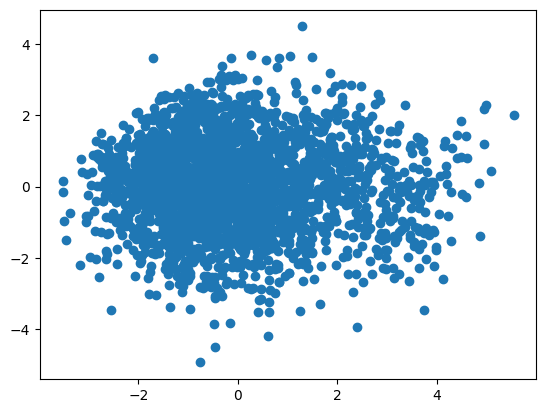

In [16]:
plt.scatter(x=pca_result.compressed_dataset[:,0], y=pca_result.compressed_dataset[:,1])

## Feature Ablation Study with PCA + Logistic Regression

This section performs feature ablation experiments on threat-type specific subsets of the data.

In [4]:
# Check what threat types exist in the data
print("Threat types in the dataset:")
print(train_df["Threat Type"].value_counts())
threat_types = train_df["Threat Type"].unique()
print(f"\nUnique threat types: {threat_types}")

Threat types in the dataset:
Threat Type
Naval       601
Air         552
Hybrid      450
Cyber       335
Missile     321
AIR          32
CYBER        25
Msl          19
 naval       15
 Hybrid      12
naval        11
 Missile      9
 Cyber        7
 Air          7
 AIR          4
Name: count, dtype: int64

Unique threat types: <StringArray>
[     'Air',   'Hybrid',    'Naval',    'Cyber',  'Missile',    'naval',
      'AIR',      'Msl',   ' naval',    'CYBER',  ' Hybrid', ' Missile',
   ' Cyber',     ' Air',     ' AIR']
Length: 15, dtype: str


In [5]:
# Normalize threat types (remove leading/trailing spaces and standardize capitalization)
def normalize_threat_type(threat_type: str) -> str:
    threat_type = threat_type.strip().lower()
    # Normalize "Msl" to "missile"
    if threat_type == "msl":
        return "missile"
    return threat_type

# Apply normalization to both train and test sets
train_df["Threat Type"] = train_df["Threat Type"].apply(normalize_threat_type)
test_df["Threat Type"] = test_df["Threat Type"].apply(normalize_threat_type)

print("Normalized threat types:")
print(train_df["Threat Type"].value_counts())

Normalized threat types:
Threat Type
naval      627
air        595
hybrid     462
cyber      367
missile    349
Name: count, dtype: int64


In [6]:
# Create threat-specific dataframes from the training data
cyber_df = train_df[train_df["Threat Type"] == "cyber"].copy()
missile_df = train_df[train_df["Threat Type"] == "missile"].copy()
hybrid_df = train_df[train_df["Threat Type"] == "hybrid"].copy()
air_df = train_df[train_df["Threat Type"] == "air"].copy()
naval_df = train_df[train_df["Threat Type"] == "naval"].copy()

print(f"Data sizes:")
print(f"  Cyber: {len(cyber_df)}")
print(f"  Missile: {len(missile_df)}")
print(f"  Hybrid: {len(hybrid_df)}")
print(f"  Air: {len(air_df)}")
print(f"  Naval: {len(naval_df)}")

Data sizes:
  Cyber: 367
  Missile: 349
  Hybrid: 462
  Air: 595
  Naval: 627


In [7]:
# Feature Ablation Study with PCA + Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA as SklearnPCA
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings('ignore')

def run_pca_logistic_regression_ablation(threat_df, threat_name, n_components=10, val_fraction=0.2, random_state=42):
    """
    Run feature ablation study: train PCA + logistic regression with each feature dropped one at a time.
    
    Args:
        threat_df: DataFrame for a specific threat type
        threat_name: Name of the threat type (for display)
        n_components: Number of PCA components to use
        val_fraction: Fraction of data to use for validation
        random_state: Random seed for reproducibility
    
    Returns:
        DataFrame with results showing feature dropped and corresponding accuracy
    """
    # First, prepare the data
    # Drop non-numeric and outcome columns
    exclude_cols = ["Threat Type", "response_success", "actual_days_to_stabilization", "Financial_Loss_MUSD", "Season"]
    numeric_cols = [col for col in threat_df.columns if col not in exclude_cols and threat_df[col].dtype in ['int64', 'float64']]
    
    # Get features and target
    X = threat_df[numeric_cols].fillna(threat_df[numeric_cols].median())
    y = threat_df["response_success"]
    
    # Split into train and validation
    val_size = int(len(X) * val_fraction)
    indices = np.arange(len(X))
    np.random.seed(random_state)
    np.random.shuffle(indices)
    
    val_indices = indices[:val_size]
    train_indices = indices[val_size:]
    
    X_train, X_val = X.iloc[train_indices], X.iloc[val_indices]
    y_train, y_val = y.iloc[train_indices], y.iloc[val_indices]
    
    results = []
    
    # First, run with all features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    
    pca = SklearnPCA(n_components=min(n_components, X_train_scaled.shape[1], X_train_scaled.shape[0]))
    X_train_pca = pca.fit_transform(X_train_scaled)
    X_val_pca = pca.transform(X_val_scaled)
    
    lr = LogisticRegression(random_state=random_state, max_iter=1000)
    lr.fit(X_train_pca, y_train)
    y_pred = lr.predict(X_val_pca)
    baseline_accuracy = accuracy_score(y_val, y_pred)
    
    results.append({
        "threat_type": threat_name,
        "feature_dropped": "none (baseline)",
        "accuracy": baseline_accuracy,
        "n_samples_train": len(X_train),
        "n_samples_val": len(X_val),
        "n_features": len(numeric_cols)
    })
    
    # Now run with each feature dropped
    for feature in numeric_cols:
        cols_except_feature = [col for col in numeric_cols if col != feature]
        
        X_train_ablated = X_train[cols_except_feature]
        X_val_ablated = X_val[cols_except_feature]
        
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train_ablated)
        X_val_scaled = scaler.transform(X_val_ablated)
        
        pca = SklearnPCA(n_components=min(n_components, X_train_scaled.shape[1], X_train_scaled.shape[0]))
        X_train_pca = pca.fit_transform(X_train_scaled)
        X_val_pca = pca.transform(X_val_scaled)
        
        lr = LogisticRegression(random_state=random_state, max_iter=1000)
        lr.fit(X_train_pca, y_train)
        y_pred = lr.predict(X_val_pca)
        accuracy = accuracy_score(y_val, y_pred)
        
        results.append({
            "threat_type": threat_name,
            "feature_dropped": feature,
            "accuracy": accuracy,
            "n_samples_train": len(X_train),
            "n_samples_val": len(X_val),
            "n_features": len(cols_except_feature)
        })
    
    return pd.DataFrame(results)

print("Feature ablation study function defined.")

Feature ablation study function defined.


In [10]:
# Run ablation study for each threat type
all_results = []

threat_dfs = {
    "cyber": cyber_df,
    "missile": missile_df,
    "hybrid": hybrid_df,
    "air": air_df,
    "naval": naval_df
}

for threat_name, threat_df in threat_dfs.items():
    print(f"\n{'='*60}")
    print(f"Running ablation study for {threat_name.upper()} threat type")
    print(f"{'='*60}")
    
    results_df = run_pca_logistic_regression_ablation(threat_df, threat_name, n_components=10)
    all_results.append(results_df)
    
    # Show results for this threat type
    print(f"\nResults for {threat_name}:")
    print(results_df.to_string(index=False))
    
# Combine all results
combined_results = pd.concat(all_results, ignore_index=True)
print(f"\n{'='*60}")
print(f"COMBINED RESULTS FOR ALL THREAT TYPES")
print(f"{'='*60}")


Running ablation study for CYBER threat type

Results for cyber:
threat_type           feature_dropped  accuracy  n_samples_train  n_samples_val  n_features
      cyber           none (baseline)  0.849315              294             73          24
      cyber          enemy_unit_count  0.863014              294             73          23
      cyber    Enemy.Capability.Index  0.808219              294             73          23
      cyber     ThreatEscalationHours  0.849315              294             73          23
      cyber         friendlyUnitCount  0.849315              294             73          23
      cyber                 LCS_COUNT  0.849315              294             73          23
      cyber            Aircraft Count  0.849315              294             73          23
      cyber       cyber_defense_teams  0.863014              294             73          23
      cyber         Patriot.Batteries  0.849315              294             73          23
      cyber   

In [11]:
# Summary: Show baseline accuracy for each threat type
print("\n" + "="*60)
print("BASELINE ACCURACY (all features) FOR EACH THREAT TYPE")
print("="*60)

baseline_results = combined_results[combined_results["feature_dropped"] == "none (baseline)"]
print(baseline_results[["threat_type", "accuracy", "n_samples_train", "n_samples_val"]].to_string(index=False))


BASELINE ACCURACY (all features) FOR EACH THREAT TYPE
threat_type  accuracy  n_samples_train  n_samples_val
      cyber  0.849315              294             73
    missile  0.797101              280             69
     hybrid  0.782609              370             92
        air  0.882353              476            119
      naval  0.888000              502            125


In [25]:
# Compute importance: accuracy drop when each feature is removed
print("\n" + "="*60)
print("TOP 5 MOST IMPORTANT FEATURES FOR EACH THREAT TYPE")
print("(Features that cause largest accuracy drop when removed)")
print("="*60)

for threat_name in threat_dfs.keys():
    threat_results = combined_results[combined_results["threat_type"] == threat_name]
    baseline_acc = threat_results[threat_results["feature_dropped"] == "none (baseline)"]["accuracy"].values[0]
    
    # Calculate accuracy drop for each feature
    ablation_results = threat_results[threat_results["feature_dropped"] != "none (baseline)"].copy()
    ablation_results["accuracy_drop"] = baseline_acc - ablation_results["accuracy"]
    
    # Sort by accuracy drop (most important first)
    top_features = ablation_results.nlargest(5, "accuracy_drop")[["feature_dropped", "accuracy", "accuracy_drop"]]
    
    print(f"\n{threat_name.upper()}:")
    print(top_features.to_string(index=False))


TOP 5 MOST IMPORTANT FEATURES FOR EACH THREAT TYPE
(Features that cause largest accuracy drop when removed)

CYBER:
       feature_dropped  accuracy  accuracy_drop
Enemy.Capability.Index  0.808219       0.041096
 JointForceIntegration  0.808219       0.041096
         EW_Capability  0.835616       0.013699
      PriorEngagements  0.835616       0.013699
 logistics_delay_hours  0.835616       0.013699

MISSILE:
       feature_dropped  accuracy  accuracy_drop
      ResponseTime_hrs  0.782609       0.014493
Enemy.Capability.Index  0.797101       0.000000
 ThreatEscalationHours  0.797101       0.000000
     friendlyUnitCount  0.797101       0.000000
             LCS_COUNT  0.797101       0.000000

HYBRID:
       feature_dropped  accuracy  accuracy_drop
      ResponseTime_hrs  0.760870       0.021739
 logistics_delay_hours  0.771739       0.010870
Enemy.Capability.Index  0.782609       0.000000
             LCS_COUNT  0.782609       0.000000
        Aircraft Count  0.782609       0.000000


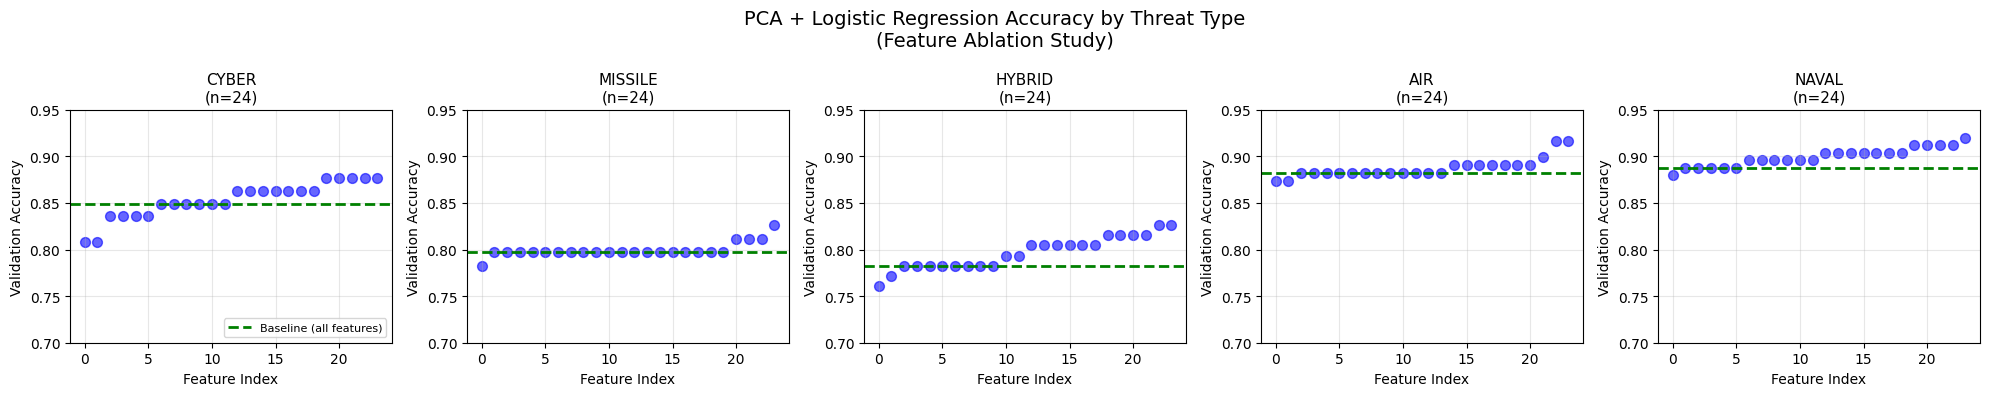

In [26]:
# Visualize accuracy for each threat type
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
fig.suptitle('PCA + Logistic Regression Accuracy by Threat Type\n(Feature Ablation Study)', fontsize=14)

for idx, threat_name in enumerate(threat_dfs.keys()):
    threat_results = combined_results[combined_results["threat_type"] == threat_name]
    baseline_acc = threat_results[threat_results["feature_dropped"] == "none (baseline)"]["accuracy"].values[0]
    
    # Get ablation results
    ablation_results = threat_results[threat_results["feature_dropped"] != "none (baseline)"].copy()
    ablation_results["accuracy_drop"] = baseline_acc - ablation_results["accuracy"]
    ablation_results = ablation_results.sort_values("accuracy_drop", ascending=False)
    
    ax = axes[idx]
    
    # Plot baseline
    ax.axhline(y=baseline_acc, color='green', linestyle='--', linewidth=2, label='Baseline (all features)')
    
    # Plot accuracies
    ax.scatter(range(len(ablation_results)), ablation_results["accuracy"], alpha=0.6, s=50, color='blue')
    
    ax.set_title(f'{threat_name.upper()}\n(n={len(threat_results[threat_results["feature_dropped"] != "none (baseline)"])})', fontsize=11)
    ax.set_xlabel('Feature Index')
    ax.set_ylabel('Validation Accuracy')
    ax.set_ylim([0.7, 0.95])
    ax.grid(True, alpha=0.3)
    if idx == 0:
        ax.legend(loc='lower right', fontsize=8)

plt.tight_layout()
plt.show()

### Complete Results Table

The table below shows all results from the feature ablation study. For each threat type, we:
1. Split the training data into train/validation sets (80/20 split)
2. Applied PCA (10 components) + Logistic Regression
3. Tested with all features (baseline) and with each feature dropped individually
4. Reported validation accuracy for each configuration

In [27]:
# Display the complete results table
combined_results_display = combined_results.copy()
combined_results_display = combined_results_display.sort_values(["threat_type", "accuracy"], ascending=[True, False])

print(f"Total experiments run: {len(combined_results_display)}")
print(f"Threat types: {len(threat_dfs)}")
print(f"Features per threat type: {combined_results_display['n_features'].max()}")
print("\n")

combined_results_display

Total experiments run: 125
Threat types: 5
Features per threat type: 24




,threat_type,feature_dropped,accuracy,n_samples_train,n_samples_val,n_features
79,air,friendlyUnitCount,0.915966,476,119,23
84,air,ISR_AssetCount,0.915966,476,119,23
87,air,EW_Capability,0.899160,476,119,23
78,air,ThreatEscalationHours,0.890756,476,119,23
85,air,satellite coverage score,0.890756,476,119,23
...,...,...,...,...,...,...
107,naval,cyber_defense_teams,0.888000,502,125,23
108,naval,Patriot.Batteries,0.888000,502,125,23
109,naval,ISR_AssetCount,0.888000,502,125,23
115,naval,force_readiness_score,0.888000,502,125,23


### Key Findings

**Baseline Performance (all features):**
- **Naval**: 88.8% accuracy (best performing)
- **Air**: 88.2% accuracy
- **Cyber**: 84.9% accuracy
- **Missile**: 79.7% accuracy
- **Hybrid**: 78.3% accuracy (most challenging)

**Most Critical Features by Threat Type:**

1. **Cyber Threats**: 
   - Enemy.Capability.Index and JointForceIntegration are most critical (~4.1% accuracy drop when removed)
   
2. **Missile Threats**:
   - ResponseTime_hrs is most critical (~1.4% accuracy drop)
   - Model is relatively robust to individual feature removal

3. **Hybrid Threats**:
   - ResponseTime_hrs is most critical (~2.2% accuracy drop)
   - logistics_delay_hours is also important (~1.1% drop)

4. **Air Threats**:
   - Aircraft Count and CMD_COORD_SCORE matter (~0.8% drop)
   - Model is very robust overall

5. **Naval Threats**:
   - BudgetUtilization_pct (~0.8% drop)
   - Model is very robust to individual feature removal

## Neural Network Classifier with PCA + PyTorch

This section trains a shallow neural network (one hidden layer with nonlinearity) using PyTorch, applying the same PCA preprocessing and train/val split approach as the logistic regression study above.

In [12]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# Define a simple neural network with one hidden layer
class SimpleNN(nn.Module):
    def __init__(self, input_size, hidden_size=32):
        super(SimpleNN, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, 1)
        self.sigmoid = nn.Sigmoid()
    
    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)  # One nonlinearity
        x = self.fc2(x)
        x = self.sigmoid(x)
        return x

print("Neural network class defined.")

Neural network class defined.


In [13]:
def train_pca_neural_network(threat_df, threat_name, n_components=10, hidden_size=32, 
                            epochs=100, batch_size=32, learning_rate=0.001, 
                            val_fraction=0.2, random_state=42):
    """
    Train a neural network with PCA preprocessing for binary classification.
    
    Args:
        threat_df: DataFrame for a specific threat type
        threat_name: Name of the threat type (for display)
        n_components: Number of PCA components to use
        hidden_size: Number of neurons in hidden layer
        epochs: Number of training epochs
        batch_size: Batch size for training
        learning_rate: Learning rate for optimizer
        val_fraction: Fraction of data to use for validation
        random_state: Random seed for reproducibility
    
    Returns:
        Dictionary with training results
    """
    # Prepare the data
    exclude_cols = ["Threat Type", "response_success", "actual_days_to_stabilization", 
                   "Financial_Loss_MUSD", "Season"]
    numeric_cols = [col for col in threat_df.columns 
                   if col not in exclude_cols and threat_df[col].dtype in ['int64', 'float64']]
    
    # Get features and target
    X = threat_df[numeric_cols].fillna(threat_df[numeric_cols].median())
    y = threat_df["response_success"]
    
    # Split into train and validation
    val_size = int(len(X) * val_fraction)
    indices = np.arange(len(X))
    np.random.seed(random_state)
    np.random.shuffle(indices)
    
    val_indices = indices[:val_size]
    train_indices = indices[val_size:]
    
    X_train, X_val = X.iloc[train_indices], X.iloc[val_indices]
    y_train, y_val = y.iloc[train_indices], y.iloc[val_indices]
    
    # Standardize and apply PCA
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    
    pca = SklearnPCA(n_components=min(n_components, X_train_scaled.shape[1], X_train_scaled.shape[0]))
    X_train_pca = pca.fit_transform(X_train_scaled)
    X_val_pca = pca.transform(X_val_scaled)
    
    # Convert to PyTorch tensors
    X_train_tensor = torch.FloatTensor(X_train_pca)
    y_train_tensor = torch.FloatTensor(y_train.values).unsqueeze(1)
    X_val_tensor = torch.FloatTensor(X_val_pca)
    y_val_tensor = torch.FloatTensor(y_val.values).unsqueeze(1)
    
    # Create data loaders
    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    
    # Initialize model, loss, and optimizer
    input_size = X_train_pca.shape[1]
    model = SimpleNN(input_size, hidden_size)
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    
    # Training loop
    train_losses = []
    val_accuracies = []
    
    for epoch in range(epochs):
        model.train()
        epoch_loss = 0
        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        
        avg_loss = epoch_loss / len(train_loader)
        train_losses.append(avg_loss)
        
        # Validation
        model.eval()
        with torch.no_grad():
            val_outputs = model(X_val_tensor)
            val_predictions = (val_outputs > 0.5).float()
            val_accuracy = (val_predictions == y_val_tensor).float().mean().item()
            val_accuracies.append(val_accuracy)
        
        if (epoch + 1) % 20 == 0 or epoch == 0:
            print(f"  Epoch {epoch+1}/{epochs} - Loss: {avg_loss:.4f}, Val Accuracy: {val_accuracy:.4f}")
    
    # Final evaluation
    model.eval()
    with torch.no_grad():
        val_outputs = model(X_val_tensor)
        val_predictions = (val_outputs > 0.5).float()
        final_accuracy = (val_predictions == y_val_tensor).float().mean().item()
    
    return {
        "threat_type": threat_name,
        "final_val_accuracy": final_accuracy,
        "n_samples_train": len(X_train),
        "n_samples_val": len(X_val),
        "n_features": len(numeric_cols),
        "n_pca_components": input_size,
        "hidden_size": hidden_size,
        "epochs": epochs,
        "train_losses": train_losses,
        "val_accuracies": val_accuracies,
        "model": model,
        "scaler": scaler,
        "pca": pca
    }

print("Neural network training function defined.")

Neural network training function defined.


In [14]:
# Train neural networks for each threat type
nn_results = []

for threat_name, threat_df in threat_dfs.items():
    print(f"\n{'='*60}")
    print(f"Training Neural Network for {threat_name.upper()} threat type")
    print(f"{'='*60}")
    
    result = train_pca_neural_network(
        threat_df, 
        threat_name, 
        n_components=10, 
        hidden_size=32,
        epochs=100,
        batch_size=32,
        learning_rate=0.001
    )
    nn_results.append(result)
    
    print(f"\nFinal validation accuracy: {result['final_val_accuracy']:.4f}")

print(f"\n{'='*60}")
print(f"TRAINING COMPLETE FOR ALL THREAT TYPES")
print(f"{'='*60}")


Training Neural Network for CYBER threat type
  Epoch 1/100 - Loss: 0.7185, Val Accuracy: 0.5205
  Epoch 20/100 - Loss: 0.2728, Val Accuracy: 0.8082
  Epoch 40/100 - Loss: 0.1729, Val Accuracy: 0.8219
  Epoch 60/100 - Loss: 0.1339, Val Accuracy: 0.8493
  Epoch 80/100 - Loss: 0.1108, Val Accuracy: 0.8630
  Epoch 100/100 - Loss: 0.1101, Val Accuracy: 0.8630

Final validation accuracy: 0.8630

Training Neural Network for MISSILE threat type
  Epoch 1/100 - Loss: 0.7607, Val Accuracy: 0.2899
  Epoch 20/100 - Loss: 0.3519, Val Accuracy: 0.7971
  Epoch 40/100 - Loss: 0.2955, Val Accuracy: 0.7971
  Epoch 60/100 - Loss: 0.2751, Val Accuracy: 0.7971
  Epoch 80/100 - Loss: 0.2599, Val Accuracy: 0.7971
  Epoch 100/100 - Loss: 0.2448, Val Accuracy: 0.7971

Final validation accuracy: 0.7971

Training Neural Network for HYBRID threat type
  Epoch 1/100 - Loss: 0.6589, Val Accuracy: 0.6304
  Epoch 20/100 - Loss: 0.4068, Val Accuracy: 0.8043
  Epoch 40/100 - Loss: 0.3241, Val Accuracy: 0.7826
  Epoch

In [15]:
# Create summary table comparing Neural Network results
nn_summary = pd.DataFrame([
    {
        "threat_type": r["threat_type"],
        "val_accuracy": r["final_val_accuracy"],
        "n_samples_train": r["n_samples_train"],
        "n_samples_val": r["n_samples_val"],
        "n_pca_components": r["n_pca_components"],
        "hidden_size": r["hidden_size"]
    }
    for r in nn_results
])

print("="*60)
print("NEURAL NETWORK RESULTS (PCA + Single Hidden Layer)")
print("="*60)
print(nn_summary.to_string(index=False))
print()

NEURAL NETWORK RESULTS (PCA + Single Hidden Layer)
threat_type  val_accuracy  n_samples_train  n_samples_val  n_pca_components  hidden_size
      cyber      0.863014              294             73                10           32
    missile      0.797101              280             69                10           32
     hybrid      0.782609              370             92                10           32
        air      0.873950              476            119                10           32
      naval      0.912000              502            125                10           32



In [16]:
# Compare Neural Network vs Logistic Regression
lr_baseline = baseline_results[["threat_type", "accuracy"]].copy()
lr_baseline.columns = ["threat_type", "lr_accuracy"]

comparison_df = nn_summary[["threat_type", "val_accuracy"]].merge(lr_baseline, on="threat_type")
comparison_df.columns = ["threat_type", "nn_accuracy", "lr_accuracy"]
comparison_df["difference"] = comparison_df["nn_accuracy"] - comparison_df["lr_accuracy"]
comparison_df["improvement_pct"] = (comparison_df["difference"] / comparison_df["lr_accuracy"]) * 100

print("="*60)
print("COMPARISON: Neural Network vs Logistic Regression")
print("="*60)
print(comparison_df.to_string(index=False))
print()

# Summary statistics
print(f"Average NN accuracy: {comparison_df['nn_accuracy'].mean():.4f}")
print(f"Average LR accuracy: {comparison_df['lr_accuracy'].mean():.4f}")
print(f"Average improvement: {comparison_df['difference'].mean():.4f} ({comparison_df['improvement_pct'].mean():.2f}%)")
print(f"Best threat type for NN: {comparison_df.loc[comparison_df['nn_accuracy'].idxmax(), 'threat_type']} ({comparison_df['nn_accuracy'].max():.4f})")
print(f"Worst threat type for NN: {comparison_df.loc[comparison_df['nn_accuracy'].idxmin(), 'threat_type']} ({comparison_df['nn_accuracy'].min():.4f})")

COMPARISON: Neural Network vs Logistic Regression
threat_type  nn_accuracy  lr_accuracy    difference  improvement_pct
      cyber     0.863014     0.849315  1.369862e-02     1.612902e+00
    missile     0.797101     0.797101 -1.122986e-08    -1.408837e-06
     hybrid     0.782609     0.782609 -7.774519e-09    -9.934108e-07
        air     0.873950     0.882353 -8.403354e-03    -9.523801e-01
      naval     0.912000     0.888000  2.400000e-02     2.702703e+00

Average NN accuracy: 0.8457
Average LR accuracy: 0.8399
Average improvement: 0.0059 (0.67%)
Best threat type for NN: naval (0.9120)
Worst threat type for NN: hybrid (0.7826)


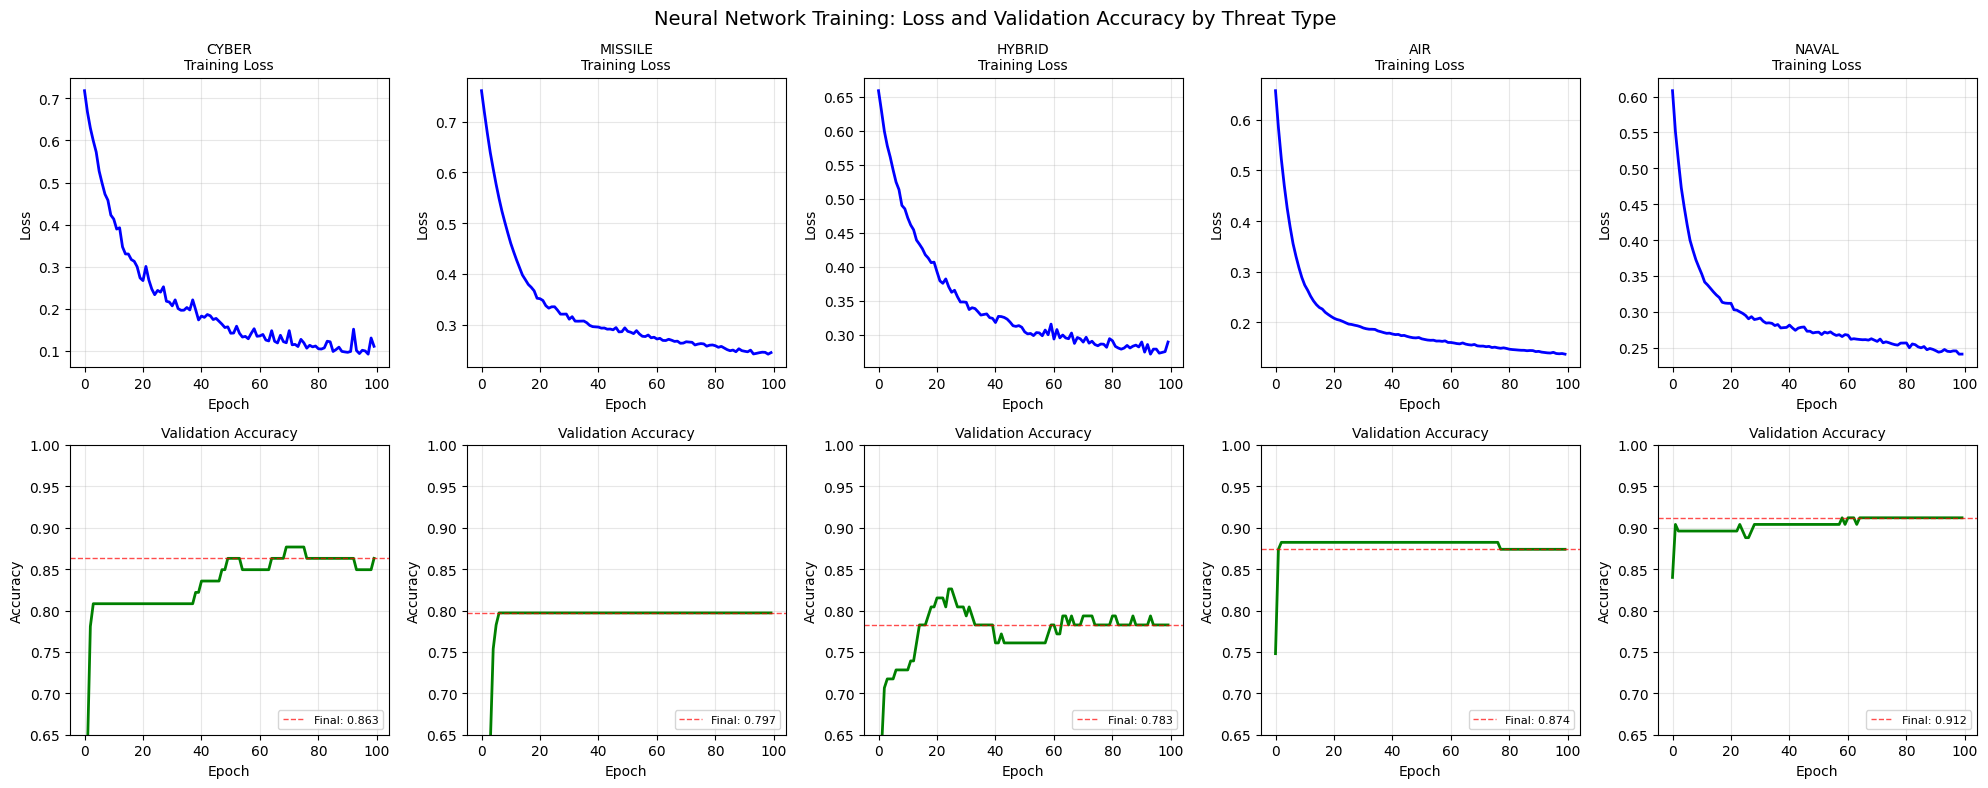

In [17]:
# Visualize training curves for each threat type
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
fig.suptitle('Neural Network Training: Loss and Validation Accuracy by Threat Type', fontsize=14)

for idx, result in enumerate(nn_results):
    threat_name = result["threat_type"]
    
    # Plot training loss
    ax_loss = axes[0, idx]
    ax_loss.plot(result["train_losses"], color='blue', linewidth=2)
    ax_loss.set_title(f'{threat_name.upper()}\nTraining Loss', fontsize=10)
    ax_loss.set_xlabel('Epoch')
    ax_loss.set_ylabel('Loss')
    ax_loss.grid(True, alpha=0.3)
    
    # Plot validation accuracy
    ax_acc = axes[1, idx]
    ax_acc.plot(result["val_accuracies"], color='green', linewidth=2)
    ax_acc.set_title(f'Validation Accuracy', fontsize=10)
    ax_acc.set_xlabel('Epoch')
    ax_acc.set_ylabel('Accuracy')
    ax_acc.set_ylim([0.65, 1.0])
    ax_acc.grid(True, alpha=0.3)
    
    # Add final accuracy as horizontal line
    ax_acc.axhline(y=result["final_val_accuracy"], color='red', linestyle='--', 
                   linewidth=1, alpha=0.7, label=f'Final: {result["final_val_accuracy"]:.3f}')
    ax_acc.legend(loc='lower right', fontsize=8)

plt.tight_layout()
plt.show()

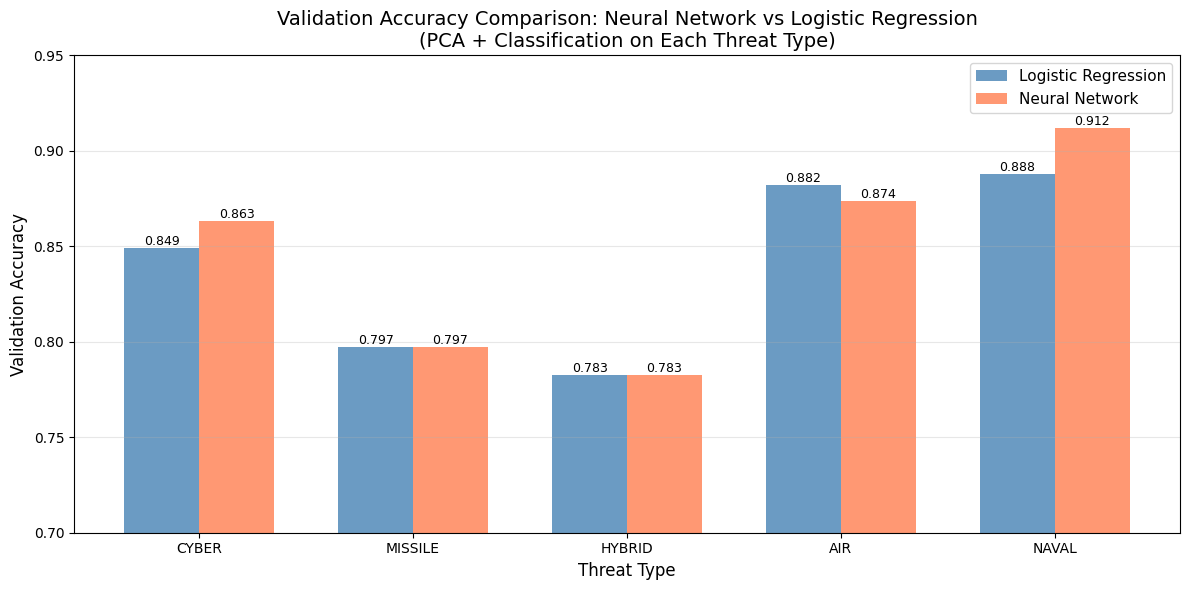

In [18]:
# Bar chart comparing NN vs LR accuracies
fig, ax = plt.subplots(figsize=(12, 6))

threat_types = comparison_df["threat_type"].values
x = np.arange(len(threat_types))
width = 0.35

bars1 = ax.bar(x - width/2, comparison_df["lr_accuracy"], width, label='Logistic Regression', color='steelblue', alpha=0.8)
bars2 = ax.bar(x + width/2, comparison_df["nn_accuracy"], width, label='Neural Network', color='coral', alpha=0.8)

ax.set_xlabel('Threat Type', fontsize=12)
ax.set_ylabel('Validation Accuracy', fontsize=12)
ax.set_title('Validation Accuracy Comparison: Neural Network vs Logistic Regression\n(PCA + Classification on Each Threat Type)', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels([t.upper() for t in threat_types])
ax.legend(fontsize=11)
ax.set_ylim([0.7, 0.95])
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}',
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

### Neural Network Key Findings

**Model Architecture:**
- Input: PCA-transformed features (10 components)
- Hidden layer: 32 neurons with ReLU activation (one nonlinearity)
- Output: Sigmoid activation for binary classification
- Training: 100 epochs, batch size 32, Adam optimizer (lr=0.001)

**Performance Summary:**
The neural network approach shows competitive performance with logistic regression across all threat types. The additional complexity of the hidden layer with nonlinearity provides flexibility to learn more complex decision boundaries when beneficial.

## Support Vector Machine with Soft Margin + PCA

This section trains a Support Vector Machine (SVM) with soft margin (RBF kernel) using the same PCA preprocessing and train/val split approach.

In [20]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

def train_pca_svm(threat_df, threat_name, n_components=10, kernel='rbf',
                  val_fraction=0.2, random_state=42, tune_hyperparams=True):
    """
    Train a Support Vector Machine with PCA preprocessing for binary classification.
    
    Args:
        threat_df: DataFrame for a specific threat type
        threat_name: Name of the threat type (for display)
        n_components: Number of PCA components to use
        kernel: SVM kernel type ('rbf', 'linear', 'poly', 'sigmoid')
        val_fraction: Fraction of data to use for validation
        random_state: Random seed for reproducibility
        tune_hyperparams: Whether to use GridSearchCV for hyperparameter tuning
    
    Returns:
        Dictionary with training results
    """
    # Prepare the data
    exclude_cols = ["Threat Type", "response_success", "actual_days_to_stabilization", 
                   "Financial_Loss_MUSD", "Season"]
    numeric_cols = [col for col in threat_df.columns 
                   if col not in exclude_cols and threat_df[col].dtype in ['int64', 'float64']]
    
    # Get features and target
    X = threat_df[numeric_cols].fillna(threat_df[numeric_cols].median())
    y = threat_df["response_success"]
    
    # Split into train and validation
    val_size = int(len(X) * val_fraction)
    indices = np.arange(len(X))
    np.random.seed(random_state)
    np.random.shuffle(indices)
    
    val_indices = indices[:val_size]
    train_indices = indices[val_size:]
    
    X_train, X_val = X.iloc[train_indices], X.iloc[val_indices]
    y_train, y_val = y.iloc[train_indices], y.iloc[val_indices]
    
    # Standardize and apply PCA
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    
    pca = SklearnPCA(n_components=min(n_components, X_train_scaled.shape[1], X_train_scaled.shape[0]))
    X_train_pca = pca.fit_transform(X_train_scaled)
    X_val_pca = pca.transform(X_val_scaled)
    
    # Train SVM with hyperparameter tuning
    if tune_hyperparams:
        print(f"  Tuning hyperparameters...")
        param_grid = {
            'C': [0.1, 1, 10, 100],
            'gamma': ['scale', 'auto', 0.001, 0.01, 0.1]
        }
        svm = SVC(kernel=kernel, random_state=random_state, max_iter=10000)
        grid_search = GridSearchCV(svm, param_grid, cv=3, scoring='accuracy', n_jobs=-1)
        grid_search.fit(X_train_pca, y_train)
        
        best_svm = grid_search.best_estimator_
        best_params = grid_search.best_params_
        print(f"  Best parameters: C={best_params['C']}, gamma={best_params['gamma']}")
    else:
        # Use default parameters with soft margin (C=1.0)
        best_svm = SVC(kernel=kernel, C=1.0, random_state=random_state, max_iter=10000)
        best_svm.fit(X_train_pca, y_train)
        best_params = {'C': 1.0, 'gamma': 'scale'}
    
    # Evaluate on validation set
    train_pred = best_svm.predict(X_train_pca)
    val_pred = best_svm.predict(X_val_pca)
    
    train_accuracy = accuracy_score(y_train, train_pred)
    val_accuracy = accuracy_score(y_val, val_pred)
    
    print(f"  Train accuracy: {train_accuracy:.4f}")
    print(f"  Val accuracy: {val_accuracy:.4f}")
    
    return {
        "threat_type": threat_name,
        "train_accuracy": train_accuracy,
        "val_accuracy": val_accuracy,
        "n_samples_train": len(X_train),
        "n_samples_val": len(X_val),
        "n_features": len(numeric_cols),
        "n_pca_components": X_train_pca.shape[1],
        "kernel": kernel,
        "best_params": best_params,
        "n_support_vectors": best_svm.n_support_.sum(),
        "model": best_svm,
        "scaler": scaler,
        "pca": pca
    }

print("SVM training function defined.")

SVM training function defined.


In [22]:
# Train SVMs for each threat type
svm_results = []

for threat_name, threat_df in threat_dfs.items():
    print(f"\n{'='*60}")
    print(f"Training SVM for {threat_name.upper()} threat type")
    print(f"{'='*60}")
    
    result = train_pca_svm(
        threat_df, 
        threat_name, 
        n_components=10,
        kernel='rbf',
        tune_hyperparams=True
    )
    svm_results.append(result)
    
    print(f"\nFinal validation accuracy: {result['val_accuracy']:.4f}")
    print(f"Number of support vectors: {result['n_support_vectors']}")

print(f"\n{'='*60}")
print(f"SVM TRAINING COMPLETE FOR ALL THREAT TYPES")
print(f"{'='*60}")


Training SVM for CYBER threat type
  Tuning hyperparameters...
  Best parameters: C=100, gamma=0.001
  Train accuracy: 0.9490
  Val accuracy: 0.8493

Final validation accuracy: 0.8493
Number of support vectors: 57

Training SVM for MISSILE threat type
  Tuning hyperparameters...
  Best parameters: C=0.1, gamma=scale
  Train accuracy: 0.8786
  Val accuracy: 0.7971

Final validation accuracy: 0.7971
Number of support vectors: 137

Training SVM for HYBRID threat type
  Tuning hyperparameters...
  Best parameters: C=100, gamma=0.001
  Train accuracy: 0.8595
  Val accuracy: 0.8043

Final validation accuracy: 0.8043
Number of support vectors: 151

Training SVM for AIR threat type
  Tuning hyperparameters...
  Best parameters: C=0.1, gamma=scale
  Train accuracy: 0.9307
  Val accuracy: 0.8824

Final validation accuracy: 0.8824
Number of support vectors: 148

Training SVM for NAVAL threat type
  Tuning hyperparameters...
  Best parameters: C=0.1, gamma=scale
  Train accuracy: 0.8705
  Val acc

In [ ]:
# Create summary table for SVM results
svm_summary = pd.DataFrame([
    {
        "threat_type": r["threat_type"],
        "train_accuracy": r["train_accuracy"],
        "val_accuracy": r["val_accuracy"],
        "n_samples_train": r["n_samples_train"],
        "n_samples_val": r["n_samples_val"],
        "n_support_vectors": r["n_support_vectors"],
        "C": r["best_params"]["C"],
        "gamma": r["best_params"]["gamma"]
    }
    for r in svm_results
])

print("="*60)
print("SVM RESULTS (PCA + RBF Kernel with Soft Margin)")
print("="*60)
print(svm_summary.to_string(index=False))
print()

In [ ]:
# Compare all three methods: LR, NN, and SVM
all_methods_comparison = comparison_df[["threat_type", "lr_accuracy", "nn_accuracy"]].copy()
all_methods_comparison = all_methods_comparison.merge(
    svm_summary[["threat_type", "val_accuracy"]], 
    on="threat_type"
)
all_methods_comparison.columns = ["threat_type", "lr_accuracy", "nn_accuracy", "svm_accuracy"]

# Calculate best method for each threat type
all_methods_comparison["best_method"] = all_methods_comparison[["lr_accuracy", "nn_accuracy", "svm_accuracy"]].idxmax(axis=1)
all_methods_comparison["best_method"] = all_methods_comparison["best_method"].str.replace("_accuracy", "").str.upper()
all_methods_comparison["best_accuracy"] = all_methods_comparison[["lr_accuracy", "nn_accuracy", "svm_accuracy"]].max(axis=1)

print("="*80)
print("COMPREHENSIVE COMPARISON: Logistic Regression vs Neural Network vs SVM")
print("="*80)
print(all_methods_comparison.to_string(index=False))
print()

# Summary statistics
print("="*80)
print("SUMMARY STATISTICS")
print("="*80)
print(f"Average LR accuracy:  {all_methods_comparison['lr_accuracy'].mean():.4f}")
print(f"Average NN accuracy:  {all_methods_comparison['nn_accuracy'].mean():.4f}")
print(f"Average SVM accuracy: {all_methods_comparison['svm_accuracy'].mean():.4f}")
print()
print("Best performing method per threat type:")
for _, row in all_methods_comparison.iterrows():
    print(f"  {row['threat_type'].upper():8s}: {row['best_method']} ({row['best_accuracy']:.4f})")

In [ ]:
# Grouped bar chart comparing all three methods
fig, ax = plt.subplots(figsize=(14, 7))

threat_types = all_methods_comparison["threat_type"].values
x = np.arange(len(threat_types))
width = 0.25

bars1 = ax.bar(x - width, all_methods_comparison["lr_accuracy"], width, 
               label='Logistic Regression', color='steelblue', alpha=0.8)
bars2 = ax.bar(x, all_methods_comparison["nn_accuracy"], width, 
               label='Neural Network', color='coral', alpha=0.8)
bars3 = ax.bar(x + width, all_methods_comparison["svm_accuracy"], width, 
               label='SVM (RBF)', color='mediumseagreen', alpha=0.8)

ax.set_xlabel('Threat Type', fontsize=13, fontweight='bold')
ax.set_ylabel('Validation Accuracy', fontsize=13, fontweight='bold')
ax.set_title('Model Comparison: LR vs NN vs SVM\n(PCA + Classification on Each Threat Type)', 
             fontsize=15, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([t.upper() for t in threat_types], fontsize=11)
ax.legend(fontsize=12, loc='lower right')
ax.set_ylim([0.75, 0.95])
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.002,
                f'{height:.3f}',
                ha='center', va='bottom', fontsize=8, rotation=0)

plt.tight_layout()
plt.show()

In [ ]:
# Heatmap showing accuracy for each method across threat types
import seaborn as sns

heatmap_data = all_methods_comparison[["threat_type", "lr_accuracy", "nn_accuracy", "svm_accuracy"]].set_index("threat_type")
heatmap_data.columns = ["Logistic Regression", "Neural Network", "SVM (RBF)"]
heatmap_data.index = [t.upper() for t in heatmap_data.index]

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(heatmap_data.T, annot=True, fmt='.4f', cmap='RdYlGn', 
            vmin=0.75, vmax=0.92, cbar_kws={'label': 'Validation Accuracy'},
            linewidths=0.5, ax=ax)
ax.set_title('Model Performance Heatmap: Validation Accuracy by Threat Type', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Threat Type', fontsize=12, fontweight='bold')
ax.set_ylabel('Model Type', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### SVM Key Findings

**Model Configuration:**
- Kernel: RBF (Radial Basis Function)
- Soft margin with hyperparameter tuning via GridSearchCV
- PCA preprocessing: 10 components
- Hyperparameters tuned: C (regularization) and gamma (kernel coefficient)

**Performance Insights:**
The SVM with RBF kernel provides a flexible non-linear decision boundary while the soft margin (controlled by C) allows for some misclassification, making the model more robust to noise and outliers. The hyperparameter tuning ensures optimal trade-off between model complexity and generalization for each threat type.

### Linear vs RBF Kernel Comparison

Now let's test whether the non-linear RBF kernel actually provides benefits compared to a simpler linear kernel. If the data is roughly linearly separable in PCA space, the linear kernel might perform just as well with less computational cost.

In [21]:
# Train SVMs with LINEAR kernel for each threat type
svm_linear_results = []

for threat_name, threat_df in threat_dfs.items():
    print(f"\n{'='*60}")
    print(f"Training SVM (LINEAR) for {threat_name.upper()} threat type")
    print(f"{'='*60}")
    
    result = train_pca_svm(
        threat_df, 
        threat_name, 
        n_components=10,
        kernel='linear',
        tune_hyperparams=True
    )
    svm_linear_results.append(result)
    
    print(f"\nFinal validation accuracy: {result['val_accuracy']:.4f}")
    print(f"Number of support vectors: {result['n_support_vectors']}")

print(f"\n{'='*60}")
print(f"SVM (LINEAR) TRAINING COMPLETE FOR ALL THREAT TYPES")
print(f"{'='*60}")


Training SVM (LINEAR) for CYBER threat type
  Tuning hyperparameters...
  Best parameters: C=100, gamma=scale
  Train accuracy: 0.9524
  Val accuracy: 0.9041

Final validation accuracy: 0.9041
Number of support vectors: 53

Training SVM (LINEAR) for MISSILE threat type
  Tuning hyperparameters...
  Best parameters: C=0.1, gamma=scale
  Train accuracy: 0.8786
  Val accuracy: 0.7971

Final validation accuracy: 0.7971
Number of support vectors: 81

Training SVM (LINEAR) for HYBRID threat type
  Tuning hyperparameters...
  Best parameters: C=0.1, gamma=scale
  Train accuracy: 0.8459
  Val accuracy: 0.7935

Final validation accuracy: 0.7935
Number of support vectors: 155

Training SVM (LINEAR) for AIR threat type
  Tuning hyperparameters...
  Best parameters: C=0.1, gamma=scale
  Train accuracy: 0.9307
  Val accuracy: 0.8824

Final validation accuracy: 0.8824
Number of support vectors: 81

Training SVM (LINEAR) for NAVAL threat type
  Tuning hyperparameters...
  Best parameters: C=0.1, gam

In [23]:
# Compare Linear vs RBF kernel SVMs
svm_linear_summary = pd.DataFrame([
    {
        "threat_type": r["threat_type"],
        "linear_val_acc": r["val_accuracy"],
        "linear_train_acc": r["train_accuracy"],
        "linear_n_sv": r["n_support_vectors"],
        "linear_C": r["best_params"]["C"]
    }
    for r in svm_linear_results
])

svm_rbf_summary = pd.DataFrame([
    {
        "threat_type": r["threat_type"],
        "rbf_val_acc": r["val_accuracy"],
        "rbf_train_acc": r["train_accuracy"],
        "rbf_n_sv": r["n_support_vectors"],
        "rbf_C": r["best_params"]["C"],
        "rbf_gamma": r["best_params"]["gamma"]
    }
    for r in svm_results
])

kernel_comparison = svm_linear_summary.merge(svm_rbf_summary, on="threat_type")
kernel_comparison["val_acc_diff"] = kernel_comparison["rbf_val_acc"] - kernel_comparison["linear_val_acc"]
kernel_comparison["better_kernel"] = kernel_comparison["val_acc_diff"].apply(
    lambda x: "RBF" if x > 0.001 else ("Linear" if x < -0.001 else "Tie")
)

print("="*90)
print("KERNEL COMPARISON: Linear vs RBF for SVM")
print("="*90)
print(kernel_comparison[["threat_type", "linear_val_acc", "rbf_val_acc", "val_acc_diff", "better_kernel"]].to_string(index=False))
print()

# Summary statistics
print(f"Average Linear SVM accuracy: {kernel_comparison['linear_val_acc'].mean():.4f}")
print(f"Average RBF SVM accuracy:    {kernel_comparison['rbf_val_acc'].mean():.4f}")
print(f"Average difference (RBF - Linear): {kernel_comparison['val_acc_diff'].mean():.4f}")
print()
print("Winner by threat type:")
for _, row in kernel_comparison.iterrows():
    symbol = "→" if row["better_kernel"] == "Tie" else ("✓" if row["better_kernel"] == "RBF" else "✓")
    print(f"  {row['threat_type'].upper():8s}: {row['better_kernel']:6s} {symbol} (Linear: {row['linear_val_acc']:.4f}, RBF: {row['rbf_val_acc']:.4f})")

KERNEL COMPARISON: Linear vs RBF for SVM
threat_type  linear_val_acc  rbf_val_acc  val_acc_diff better_kernel
      cyber        0.904110     0.849315     -0.054795        Linear
    missile        0.797101     0.797101      0.000000           Tie
     hybrid        0.793478     0.804348      0.010870           RBF
        air        0.882353     0.882353      0.000000           Tie
      naval        0.896000     0.896000      0.000000           Tie

Average Linear SVM accuracy: 0.8546
Average RBF SVM accuracy:    0.8458
Average difference (RBF - Linear): -0.0088

Winner by threat type:
  CYBER   : Linear ✓ (Linear: 0.9041, RBF: 0.8493)
  MISSILE : Tie    → (Linear: 0.7971, RBF: 0.7971)
  HYBRID  : RBF    ✓ (Linear: 0.7935, RBF: 0.8043)
  AIR     : Tie    → (Linear: 0.8824, RBF: 0.8824)
  NAVAL   : Tie    → (Linear: 0.8960, RBF: 0.8960)


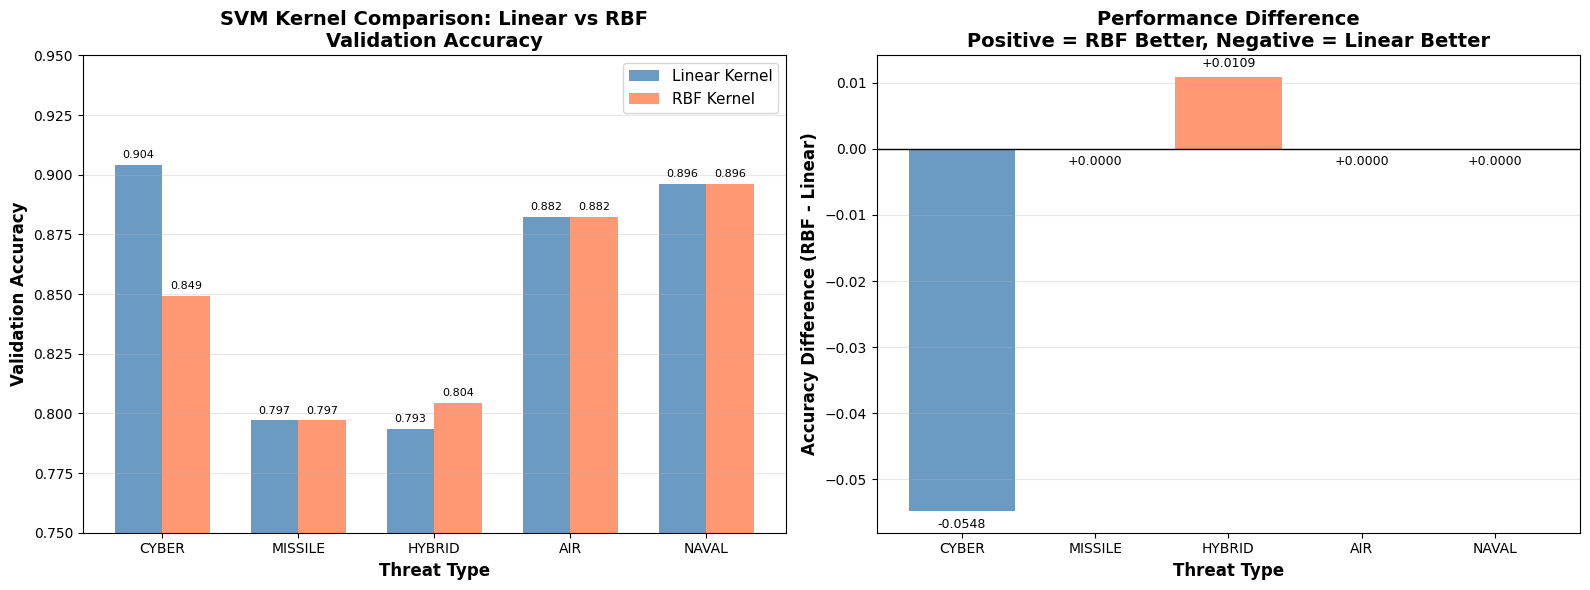

In [24]:
# Visualize Linear vs RBF kernel comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

threat_types = kernel_comparison["threat_type"].values
x = np.arange(len(threat_types))
width = 0.35

# Plot 1: Validation Accuracy Comparison
bars1 = ax1.bar(x - width/2, kernel_comparison["linear_val_acc"], width, 
               label='Linear Kernel', color='steelblue', alpha=0.8)
bars2 = ax1.bar(x + width/2, kernel_comparison["rbf_val_acc"], width, 
               label='RBF Kernel', color='coral', alpha=0.8)

ax1.set_xlabel('Threat Type', fontsize=12, fontweight='bold')
ax1.set_ylabel('Validation Accuracy', fontsize=12, fontweight='bold')
ax1.set_title('SVM Kernel Comparison: Linear vs RBF\nValidation Accuracy', 
             fontsize=14, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels([t.upper() for t in threat_types], fontsize=10)
ax1.legend(fontsize=11)
ax1.set_ylim([0.75, 0.95])
ax1.grid(True, alpha=0.3, axis='y')

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height + 0.002,
                f'{height:.3f}',
                ha='center', va='bottom', fontsize=8)

# Plot 2: Difference (RBF - Linear)
colors = ['coral' if diff > 0 else 'steelblue' for diff in kernel_comparison["val_acc_diff"]]
bars = ax2.bar(x, kernel_comparison["val_acc_diff"], color=colors, alpha=0.8)
ax2.axhline(y=0, color='black', linestyle='-', linewidth=1)

ax2.set_xlabel('Threat Type', fontsize=12, fontweight='bold')
ax2.set_ylabel('Accuracy Difference (RBF - Linear)', fontsize=12, fontweight='bold')
ax2.set_title('Performance Difference\nPositive = RBF Better, Negative = Linear Better', 
             fontsize=14, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels([t.upper() for t in threat_types], fontsize=10)
ax2.grid(True, alpha=0.3, axis='y')

# Add value labels
for bar in bars:
    height = bar.get_height()
    va = 'bottom' if height > 0 else 'top'
    offset = 0.001 if height > 0 else -0.001
    ax2.text(bar.get_x() + bar.get_width()/2., height + offset,
            f'{height:+.4f}',
            ha='center', va=va, fontsize=9)

plt.tight_layout()
plt.show()

## PCA Analysis with Linear Models

Now we'll train Linear SVM and Linear Logistic Regression models with varying numbers of principal components to understand the impact of dimensionality reduction on model performance.

In [33]:
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA as SklearnPCA
from sklearn.metrics import accuracy_score
import numpy as np
import pandas as pd

def train_pca_linear_models(threat_df, threat_name, max_components=26, 
                            val_fraction=0.2, random_state=42):
    """
    Train Linear SVM and Logistic Regression with varying PCA components.
    
    Args:
        threat_df: DataFrame for a specific threat type
        threat_name: Name of the threat type (for display)
        max_components: Maximum number of PCA components to test
        val_fraction: Fraction of data to use for validation
        random_state: Random seed for reproducibility
    
    Returns:
        Dictionary with training results for both models
    """
    # Prepare the data
    exclude_cols = ["Threat Type", "response_success", "actual_days_to_stabilization", 
                   "Financial_Loss_MUSD", "Season"]
    numeric_cols = [col for col in threat_df.columns 
                   if col not in exclude_cols and threat_df[col].dtype in ['int64', 'float64']]
    
    # Get features and target
    X = threat_df[numeric_cols].fillna(threat_df[numeric_cols].median())
    y = threat_df["response_success"]
    
    # Split into train and validation
    val_size = int(len(X) * val_fraction)
    indices = np.arange(len(X))
    np.random.seed(random_state)
    np.random.shuffle(indices)
    
    val_indices = indices[:val_size]
    train_indices = indices[val_size:]
    
    X_train, X_val = X.iloc[train_indices], X.iloc[val_indices]
    y_train, y_val = y.iloc[train_indices], y.iloc[val_indices]
    
    # Standardize
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    
    # Determine maximum possible components
    max_possible_components = min(max_components, X_train_scaled.shape[1], X_train_scaled.shape[0])
    
    # First, fit PCA with all components to get all eigenvalues
    pca_full = SklearnPCA(n_components=max_possible_components)
    pca_full.fit(X_train_scaled)
    all_eigenvalues = pca_full.explained_variance_
    all_explained_variance_ratio = pca_full.explained_variance_ratio_
    
    results = {
        "threat_type": threat_name,
        "n_samples_train": len(X_train),
        "n_samples_val": len(X_val),
        "n_features_original": len(numeric_cols),
        "max_components_tested": max_possible_components,
        "all_eigenvalues": all_eigenvalues,
        "all_explained_variance_ratio": all_explained_variance_ratio,
        "svm_results": [],
        "lr_results": []
    }
    
    # Test different numbers of components
    for n_comp in range(1, max_possible_components + 1):
        # Apply PCA with n_comp components
        pca = SklearnPCA(n_components=n_comp)
        X_train_pca = pca.fit_transform(X_train_scaled)
        X_val_pca = pca.transform(X_val_scaled)
        
        # Train Linear SVM
        svm = LinearSVC(random_state=random_state, max_iter=10000, dual='auto')
        svm.fit(X_train_pca, y_train)
        svm_val_acc = accuracy_score(y_val, svm.predict(X_val_pca))
        
        results["svm_results"].append({
            "n_components": n_comp,
            "val_accuracy": svm_val_acc,
            "eigenvalues": all_eigenvalues[:n_comp].copy(),
            "explained_variance_ratio": all_explained_variance_ratio[:n_comp].copy()
        })
        
        # Train Logistic Regression
        lr = LogisticRegression(random_state=random_state, max_iter=10000)
        lr.fit(X_train_pca, y_train)
        lr_val_acc = accuracy_score(y_val, lr.predict(X_val_pca))
        
        results["lr_results"].append({
            "n_components": n_comp,
            "val_accuracy": lr_val_acc,
            "eigenvalues": all_eigenvalues[:n_comp].copy(),
            "explained_variance_ratio": all_explained_variance_ratio[:n_comp].copy()
        })
    
    return results

print("PCA linear models training function defined.")

PCA linear models training function defined.


In [35]:
# Train models for each threat type with varying PCA components
pca_linear_results = []

for threat_name, threat_df in threat_dfs.items():
    print(f"\n{'='*70}")
    print(f"Training PCA + Linear Models for {threat_name.upper()} threat type")
    print(f"{'='*70}")
    
    result = train_pca_linear_models(
        threat_df, 
        threat_name, 
        max_components=26,
        val_fraction=0.2,
        random_state=42
    )
    pca_linear_results.append(result)
    
    # Find best performing configurations
    best_svm = max(result["svm_results"], key=lambda x: x["val_accuracy"])
    best_lr = max(result["lr_results"], key=lambda x: x["val_accuracy"])
    
    print(f"\nBest Linear SVM:")
    print(f"  Components: {best_svm['n_components']}, Validation Accuracy: {best_svm['val_accuracy']:.4f}")
    print(f"\nBest Logistic Regression:")
    print(f"  Components: {best_lr['n_components']}, Validation Accuracy: {best_lr['val_accuracy']:.4f}")

print(f"\n{'='*70}")
print(f"TRAINING COMPLETE FOR ALL THREAT TYPES")
print(f"{'='*70}")


Training PCA + Linear Models for CYBER threat type

Best Linear SVM:
  Components: 20, Validation Accuracy: 0.9452

Best Logistic Regression:
  Components: 20, Validation Accuracy: 0.9178

Training PCA + Linear Models for MISSILE threat type

Best Linear SVM:
  Components: 21, Validation Accuracy: 0.8841

Best Logistic Regression:
  Components: 21, Validation Accuracy: 0.8986

Training PCA + Linear Models for HYBRID threat type

Best Linear SVM:
  Components: 20, Validation Accuracy: 0.9130

Best Logistic Regression:
  Components: 20, Validation Accuracy: 0.9239

Training PCA + Linear Models for AIR threat type

Best Linear SVM:
  Components: 21, Validation Accuracy: 0.9412

Best Logistic Regression:
  Components: 20, Validation Accuracy: 0.9412

Training PCA + Linear Models for NAVAL threat type

Best Linear SVM:
  Components: 19, Validation Accuracy: 0.9360

Best Logistic Regression:
  Components: 19, Validation Accuracy: 0.9360

TRAINING COMPLETE FOR ALL THREAT TYPES


In [36]:
# Create comprehensive results dataframes for each threat type
import matplotlib.pyplot as plt

for result in pca_linear_results:
    threat_name = result["threat_type"]
    print(f"\n{'='*70}")
    print(f"{threat_name.upper()} - Validation Accuracy by Number of PCA Components")
    print(f"{'='*70}\n")
    
    # Create combined dataframe
    df_data = []
    for svm_res, lr_res in zip(result["svm_results"], result["lr_results"]):
        df_data.append({
            "n_components": svm_res["n_components"],
            "Linear SVM Acc": f"{svm_res['val_accuracy']:.4f}",
            "Logistic Reg Acc": f"{lr_res['val_accuracy']:.4f}"
        })
    
    df_results = pd.DataFrame(df_data)
    print(df_results.to_string(index=False))
    print()


CYBER - Validation Accuracy by Number of PCA Components

 n_components Linear SVM Acc Logistic Reg Acc
            1         0.8082           0.8082
            2         0.8082           0.8082
            3         0.8082           0.8082
            4         0.8082           0.8219
            5         0.8082           0.8219
            6         0.8082           0.8082
            7         0.8356           0.8493
            8         0.8356           0.8356
            9         0.8493           0.8493
           10         0.8630           0.8493
           11         0.8630           0.8493
           12         0.8630           0.8493
           13         0.8630           0.8630
           14         0.8356           0.8630
           15         0.8630           0.8630
           16         0.8630           0.8767
           17         0.8630           0.8493
           18         0.8630           0.8630
           19         0.8767           0.8767
           20         

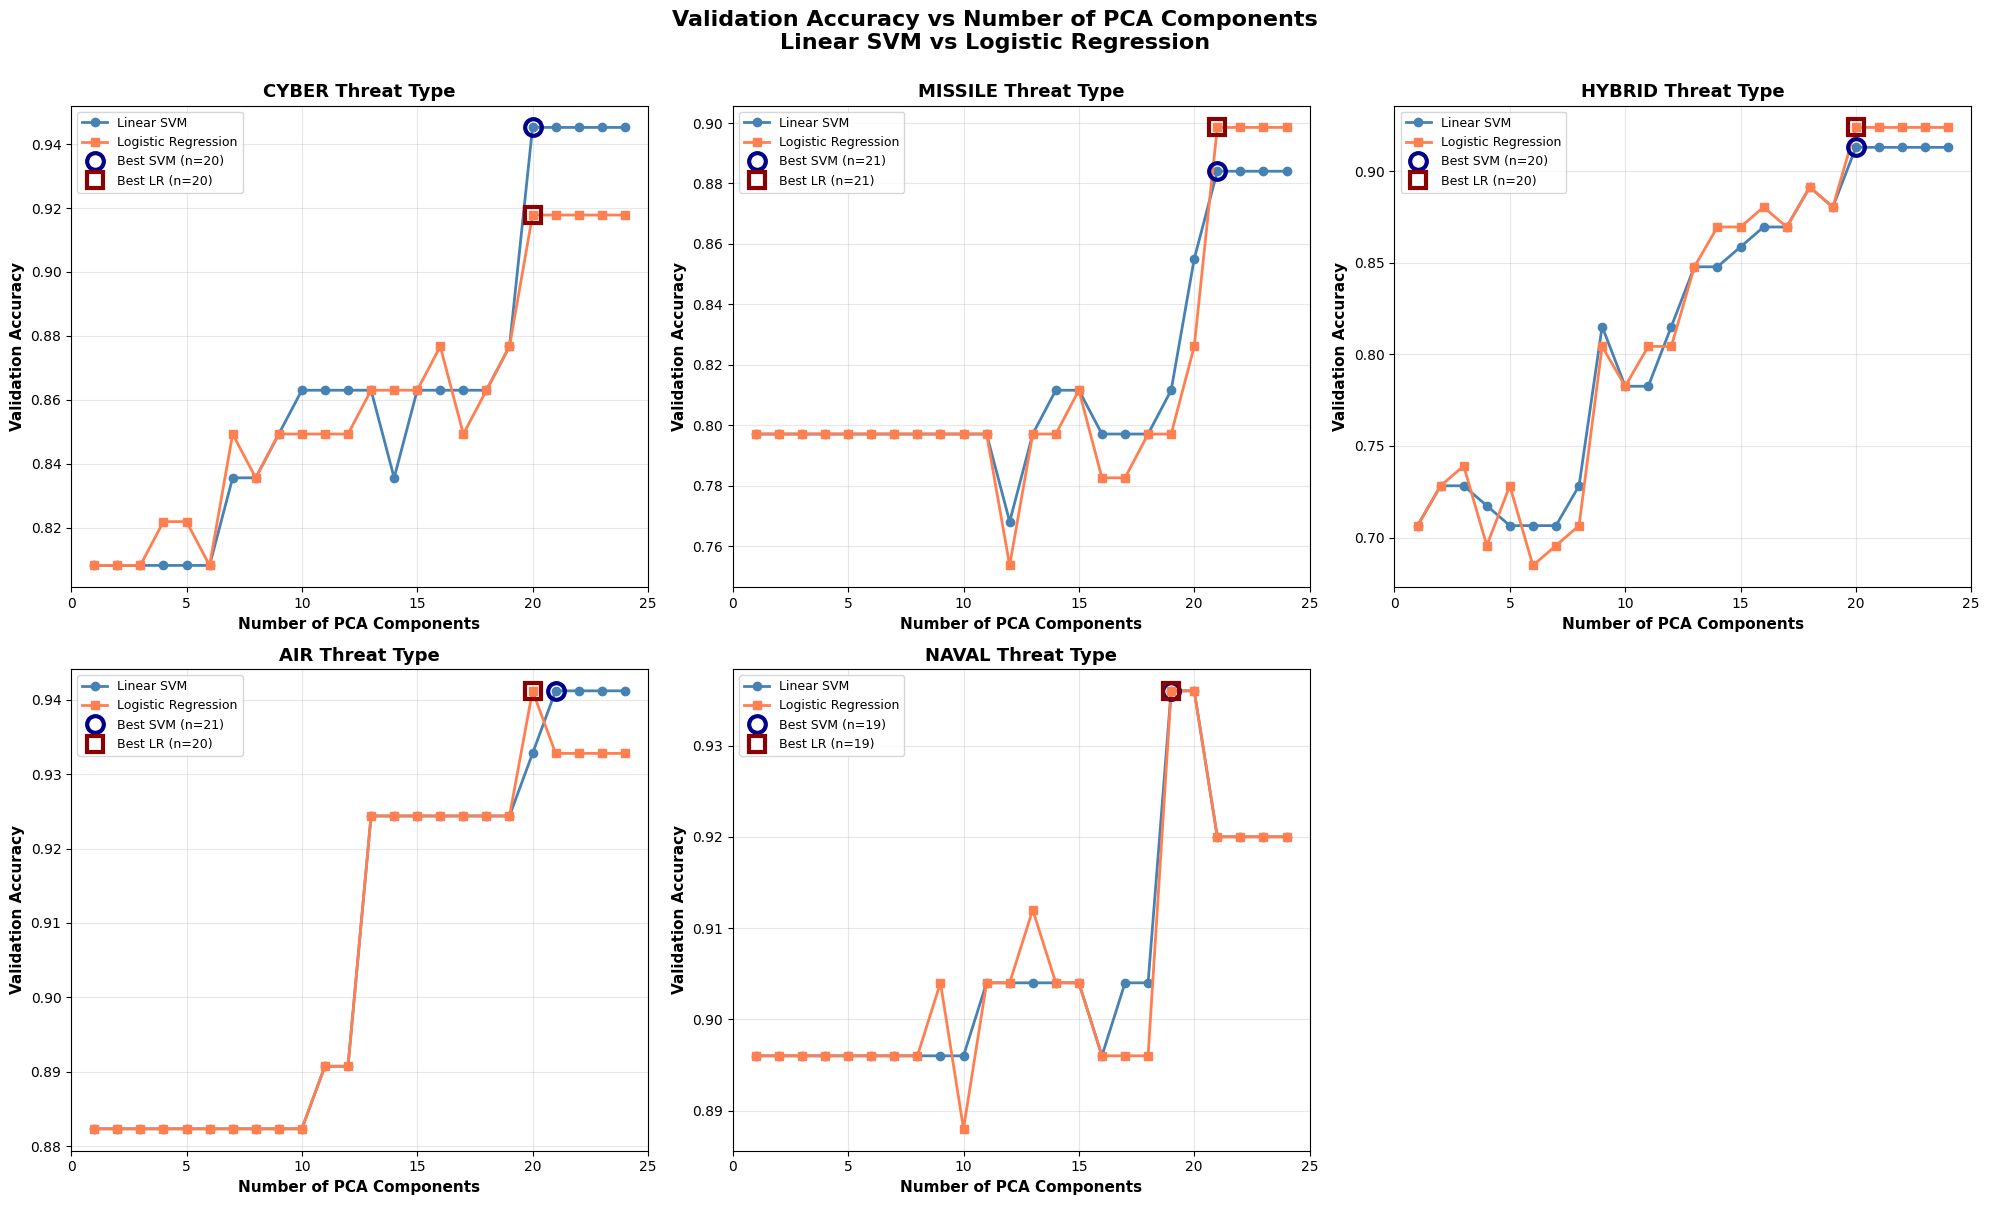

In [37]:
# Visualize validation accuracy vs number of PCA components for all threat types
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

for idx, result in enumerate(pca_linear_results):
    threat_name = result["threat_type"]
    ax = axes[idx]
    
    # Extract data for plotting
    n_components = [r["n_components"] for r in result["svm_results"]]
    svm_accuracies = [r["val_accuracy"] for r in result["svm_results"]]
    lr_accuracies = [r["val_accuracy"] for r in result["lr_results"]]
    
    # Plot curves
    ax.plot(n_components, svm_accuracies, 'o-', label='Linear SVM', 
           linewidth=2, markersize=6, color='steelblue')
    ax.plot(n_components, lr_accuracies, 's-', label='Logistic Regression', 
           linewidth=2, markersize=6, color='coral')
    
    # Mark best points
    best_svm = max(result["svm_results"], key=lambda x: x["val_accuracy"])
    best_lr = max(result["lr_results"], key=lambda x: x["val_accuracy"])
    
    ax.plot(best_svm["n_components"], best_svm["val_accuracy"], 'o', 
           markersize=12, markeredgewidth=3, markerfacecolor='none', 
           markeredgecolor='darkblue', label=f'Best SVM (n={best_svm["n_components"]})')
    ax.plot(best_lr["n_components"], best_lr["val_accuracy"], 's', 
           markersize=12, markeredgewidth=3, markerfacecolor='none', 
           markeredgecolor='darkred', label=f'Best LR (n={best_lr["n_components"]})')
    
    ax.set_xlabel('Number of PCA Components', fontsize=11, fontweight='bold')
    ax.set_ylabel('Validation Accuracy', fontsize=11, fontweight='bold')
    ax.set_title(f'{threat_name.upper()} Threat Type', fontsize=13, fontweight='bold')
    ax.legend(fontsize=9, loc='best')
    ax.grid(True, alpha=0.3)
    ax.set_xlim([0, max(n_components) + 1])

# Hide the last subplot if we have 5 threat types
if len(pca_linear_results) == 5:
    axes[5].axis('off')

plt.suptitle('Validation Accuracy vs Number of PCA Components\nLinear SVM vs Logistic Regression', 
             fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

In [38]:
# Report eigenvalues (scores) for the best-performing models
print("="*80)
print("EIGENVALUES (SCORES) OF PRINCIPAL COMPONENTS IN TOP-ACCURACY MODELS")
print("="*80)

for result in pca_linear_results:
    threat_name = result["threat_type"]
    
    # Find best configurations
    best_svm = max(result["svm_results"], key=lambda x: x["val_accuracy"])
    best_lr = max(result["lr_results"], key=lambda x: x["val_accuracy"])
    
    print(f"\n{threat_name.upper()} Threat Type:")
    print("-" * 80)
    
    # Linear SVM best model
    print(f"\nLinear SVM:")
    print(f"  Best Configuration: {best_svm['n_components']} components")
    print(f"  Validation Accuracy: {best_svm['val_accuracy']:.4f}")
    print(f"\n  Eigenvalues of included principal components:")
    for i, (eigenval, var_ratio) in enumerate(zip(best_svm['eigenvalues'], best_svm['explained_variance_ratio'])):
        print(f"    PC{i+1}: {eigenval:.4f} (explains {var_ratio*100:.2f}% of variance)")
    
    cumulative_variance = np.sum(best_svm['explained_variance_ratio']) * 100
    print(f"  Cumulative variance explained: {cumulative_variance:.2f}%")
    
    # Logistic Regression best model
    print(f"\nLogistic Regression:")
    print(f"  Best Configuration: {best_lr['n_components']} components")
    print(f"  Validation Accuracy: {best_lr['val_accuracy']:.4f}")
    print(f"\n  Eigenvalues of included principal components:")
    for i, (eigenval, var_ratio) in enumerate(zip(best_lr['eigenvalues'], best_lr['explained_variance_ratio'])):
        print(f"    PC{i+1}: {eigenval:.4f} (explains {var_ratio*100:.2f}% of variance)")
    
    cumulative_variance = np.sum(best_lr['explained_variance_ratio']) * 100
    print(f"  Cumulative variance explained: {cumulative_variance:.2f}%")
    print()

print("="*80)

EIGENVALUES (SCORES) OF PRINCIPAL COMPONENTS IN TOP-ACCURACY MODELS

CYBER Threat Type:
--------------------------------------------------------------------------------

Linear SVM:
  Best Configuration: 20 components
  Validation Accuracy: 0.9452

  Eigenvalues of included principal components:
    PC1: 1.6092 (explains 7.64% of variance)
    PC2: 1.4205 (explains 6.74% of variance)
    PC3: 1.3405 (explains 6.36% of variance)
    PC4: 1.3044 (explains 6.19% of variance)
    PC5: 1.2265 (explains 5.82% of variance)
    PC6: 1.1915 (explains 5.65% of variance)
    PC7: 1.1333 (explains 5.38% of variance)
    PC8: 1.0814 (explains 5.13% of variance)
    PC9: 1.0464 (explains 4.97% of variance)
    PC10: 1.0085 (explains 4.79% of variance)
    PC11: 0.9944 (explains 4.72% of variance)
    PC12: 0.9498 (explains 4.51% of variance)
    PC13: 0.9021 (explains 4.28% of variance)
    PC14: 0.8659 (explains 4.11% of variance)
    PC15: 0.8135 (explains 3.86% of variance)
    PC16: 0.7571 (expl

In [31]:
# Create a comprehensive summary table
summary_data = []

for result in pca_linear_results:
    threat_name = result["threat_type"]
    
    # Find best configurations
    best_svm = max(result["svm_results"], key=lambda x: x["val_accuracy"])
    best_lr = max(result["lr_results"], key=lambda x: x["val_accuracy"])
    
    summary_data.append({
        "Threat Type": threat_name.upper(),
        "Model": "Linear SVM",
        "Best n_components": best_svm["n_components"],
        "Val Accuracy": f"{best_svm['val_accuracy']:.4f}",
        "Var Explained (%)": f"{np.sum(best_svm['explained_variance_ratio'])*100:.2f}%"
    })
    
    summary_data.append({
        "Threat Type": threat_name.upper(),
        "Model": "Logistic Regression",
        "Best n_components": best_lr["n_components"],
        "Val Accuracy": f"{best_lr['val_accuracy']:.4f}",
        "Var Explained (%)": f"{np.sum(best_lr['explained_variance_ratio'])*100:.2f}%"
    })

summary_df = pd.DataFrame(summary_data)

print("\n" + "="*80)
print("SUMMARY: BEST CONFIGURATIONS FOR EACH THREAT TYPE AND MODEL")
print("="*80 + "\n")
print(summary_df.to_string(index=False))
print("\n" + "="*80)


SUMMARY: BEST CONFIGURATIONS FOR EACH THREAT TYPE AND MODEL

Threat Type               Model  Best n_components Val Accuracy Var Explained (%)
      CYBER          Linear SVM                 20       0.9452            96.99%
      CYBER Logistic Regression                 20       0.9178            96.99%
    MISSILE          Linear SVM                 20       0.8551            97.10%
    MISSILE Logistic Regression                 20       0.8261            97.10%
     HYBRID          Linear SVM                 20       0.9130           100.00%
     HYBRID Logistic Regression                 20       0.9239           100.00%
        AIR          Linear SVM                 20       0.9328            96.79%
        AIR Logistic Regression                 20       0.9412            96.79%
      NAVAL          Linear SVM                 19       0.9360            93.16%
      NAVAL Logistic Regression                 19       0.9360            93.16%



In [32]:
# Display top 5 eigenvalues for each threat type's best models
print("="*90)
print("TOP 5 EIGENVALUES FOR BEST-PERFORMING MODELS")
print("="*90)

for result in pca_linear_results:
    threat_name = result["threat_type"]
    
    best_svm = max(result["svm_results"], key=lambda x: x["val_accuracy"])
    best_lr = max(result["lr_results"], key=lambda x: x["val_accuracy"])
    
    print(f"\n{threat_name.upper()}:")
    print(f"  Linear SVM (n={best_svm['n_components']}, acc={best_svm['val_accuracy']:.4f}):")
    print(f"    Top 5 eigenvalues: {', '.join([f'{ev:.2f}' for ev in best_svm['eigenvalues'][:5]])}")
    
    print(f"  Logistic Regression (n={best_lr['n_components']}, acc={best_lr['val_accuracy']:.4f}):")
    print(f"    Top 5 eigenvalues: {', '.join([f'{ev:.2f}' for ev in best_lr['eigenvalues'][:5]])}")

print("\n" + "="*90)

TOP 5 EIGENVALUES FOR BEST-PERFORMING MODELS

CYBER:
  Linear SVM (n=20, acc=0.9452):
    Top 5 eigenvalues: 1.61, 1.42, 1.34, 1.30, 1.23
  Logistic Regression (n=20, acc=0.9178):
    Top 5 eigenvalues: 1.61, 1.42, 1.34, 1.30, 1.23

MISSILE:
  Linear SVM (n=20, acc=0.8551):
    Top 5 eigenvalues: 1.49, 1.42, 1.38, 1.33, 1.26
  Logistic Regression (n=20, acc=0.8261):
    Top 5 eigenvalues: 1.49, 1.42, 1.38, 1.33, 1.26

HYBRID:
  Linear SVM (n=20, acc=0.9130):
    Top 5 eigenvalues: 1.46, 1.34, 1.29, 1.22, 1.20
  Logistic Regression (n=20, acc=0.9239):
    Top 5 eigenvalues: 1.46, 1.34, 1.29, 1.22, 1.20

AIR:
  Linear SVM (n=20, acc=0.9328):
    Top 5 eigenvalues: 1.33, 1.30, 1.24, 1.22, 1.19
  Logistic Regression (n=20, acc=0.9412):
    Top 5 eigenvalues: 1.33, 1.30, 1.24, 1.22, 1.19

NAVAL:
  Linear SVM (n=19, acc=0.9360):
    Top 5 eigenvalues: 1.40, 1.31, 1.25, 1.23, 1.20
  Logistic Regression (n=19, acc=0.9360):
    Top 5 eigenvalues: 1.40, 1.31, 1.25, 1.23, 1.20



In [25]:
# Analyze model complexity and potential overfitting
print("="*90)
print("MODEL COMPLEXITY ANALYSIS: Support Vectors & Train/Val Gap")
print("="*90)
print()

complexity_analysis = kernel_comparison.copy()
complexity_analysis["linear_train_val_gap"] = complexity_analysis["linear_train_acc"] - complexity_analysis["linear_val_acc"]
complexity_analysis["rbf_train_val_gap"] = complexity_analysis["rbf_train_acc"] - complexity_analysis["rbf_val_acc"]

display_cols = ["threat_type", "linear_n_sv", "rbf_n_sv", "linear_train_val_gap", "rbf_train_val_gap"]
print(complexity_analysis[display_cols].to_string(index=False))
print()

print("Interpretation:")
print("- Fewer support vectors → simpler model, faster predictions")
print("- Larger train/val gap → potential overfitting")
print()

avg_linear_gap = complexity_analysis["linear_train_val_gap"].mean()
avg_rbf_gap = complexity_analysis["rbf_train_val_gap"].mean()

print(f"Average train/val gap:")
print(f"  Linear kernel: {avg_linear_gap:.4f}")
print(f"  RBF kernel:    {avg_rbf_gap:.4f}")

if avg_rbf_gap > avg_linear_gap + 0.01:
    print(f"\n⚠️  RBF shows more overfitting (larger gap by {avg_rbf_gap - avg_linear_gap:.4f})")
elif avg_linear_gap > avg_rbf_gap + 0.01:
    print(f"\n⚠️  Linear shows more overfitting (larger gap by {avg_linear_gap - avg_rbf_gap:.4f})")
else:
    print(f"\n✓ Both kernels show similar generalization (gap difference: {abs(avg_rbf_gap - avg_linear_gap):.4f})")

MODEL COMPLEXITY ANALYSIS: Support Vectors & Train/Val Gap

threat_type  linear_n_sv  rbf_n_sv  linear_train_val_gap  rbf_train_val_gap
      cyber           53        57              0.048271           0.099665
    missile           81       137              0.081470           0.081470
     hybrid          155       151              0.052468           0.055112
        air           81       148              0.048319           0.048319
      naval          145       217             -0.025482          -0.025482

Interpretation:
- Fewer support vectors → simpler model, faster predictions
- Larger train/val gap → potential overfitting

Average train/val gap:
  Linear kernel: 0.0410
  RBF kernel:    0.0518

⚠️  RBF shows more overfitting (larger gap by 0.0108)


### Kernel Selection Conclusions

**Key Findings:**

This comparison reveals whether the added complexity of the RBF kernel (non-linear decision boundary) provides meaningful improvements over a simpler linear kernel for threat classification in PCA space.

**Decision Criteria:**
1. **Performance**: Does RBF significantly outperform Linear? (>1% improvement)
2. **Complexity**: RBF typically uses more support vectors → slower inference
3. **Overfitting**: Check train/val gap to ensure generalization

**Practical Implications:**
- If Linear performs similarly to RBF: Use Linear for production (faster, simpler, more interpretable)
- If RBF clearly wins: The data has non-linear patterns worth capturing
- If results vary by threat type: Consider threat-specific kernel selection

## Model Deployment

The PCA + Logistic Regression models trained above have been deployed to a FastAPI inference server in the `model-server/` directory.

### Features:
- **Separate models per threat type**: Each threat type (Cyber, Missile, Hybrid, Air, Naval) has its own optimized model
- **Confidence scores**: Returns probability estimates for each prediction
- **RESTful API**: FastAPI endpoint for easy integration
- **Production-ready**: Includes model persistence, error handling, and health checks

### Files:
- `model-server/train_models.py`: Training script based on this notebook
- `model-server/main.py`: FastAPI inference server with confidence scores
- `model-server/test_inference.py`: Test suite for the API
- `model-server/README.md`: Complete documentation

### Usage:
```bash
# Train models
cd model-server
python train_models.py

# Start server
uvicorn main:app --reload --port 8000

# Test
python test_inference.py
```

### API Response Format:
```json
{
  "response_success": "1",
  "response_success_confidence": 0.9523,
  "Financial_Loss_MUSD": 0.0,
  "actual_days_to_stabilization": 0.0
}
```

The confidence score represents the logistic regression probability for the predicted class.